In [1]:
%load_ext autoreload

In [3]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import metapredict as meta
from sparrow import Protein

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

[autoreload of scipy.stats._warnings_errors failed: Traceback (most recent call last):
  File "/opt/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/opt/anaconda3/envs/jupyter_env/lib/python3.10/importlib/__init__.py", line 159, in reload
    raise ImportError(msg.format(parent_name),
ImportError: parent 'scipy.stats' not in sys.modules
]
[autoreload of scipy.sparse._sputils failed: Traceback (most recent call last):
  File "/opt/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/opt/anaconda3/envs/jupyter_env/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module

# 1. Starting with just Sog1

In [20]:
# AD SCORE
# ArTh WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh", pos_regex = r'\.(\d+)')
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211


In [21]:
# DISORDER
BasicArTh["avg_disorder_prob"] = BasicArTh["tile"].apply(lambda s: np.mean(meta.predict_disorder(s)))
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,avg_disorder_prob
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995,0.770475
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509,0.716080
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211,0.600137


In [22]:
# HELICITY
def percent_helicity(seq):
    P = Protein(seq) 
    output = P.predictor.dssp_helicity(mode = 'probability')
    return sum(output) / len(output)

BasicArTh["avg_helicity_prob"] = BasicArTh["tile"].apply(lambda s: percent_helicity(s))
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,avg_disorder_prob,avg_helicity_prob
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995,0.770475,0.245707
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509,0.716080,0.142261
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211,0.600137,0.102768


In [63]:
# CHARGE
BasicArTh["charge_prop"] = BasicArTh["tile"].str.count("R") + BasicArTh["tile"].str.count("K") - BasicArTh["tile"].str.count("D") - BasicArTh["tile"].str.count("E")
BasicArTh["charge_prop"] = BasicArTh["charge_prop"]/40
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,avg_disorder_prob,avg_helicity_prob,charge,WFYL,charge_prop
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995,0.770475,0.245707,4,3,0.100
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509,0.716080,0.142261,3,1,0.075
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211,0.600137,0.102768,0,3,0.000


In [64]:
# AROMATICS
BasicArTh["WFYL_prop"] = BasicArTh["tile"].str.count("W") + BasicArTh["tile"].str.count("F") + BasicArTh["tile"].str.count("Y") + BasicArTh["tile"].str.count("L")
BasicArTh["WFYL_prop"] = BasicArTh["WFYL_prop"] / 40
BasicArTh.head(3)

,Start,End,Description,Other,mid,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,avg_disorder_prob,avg_helicity_prob,charge,WFYL,charge_prop,WFYL_prop
0,1,40,BasicArTh.1,Q6NQK2,21,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995,0.770475,0.245707,4,3,0.100,0.075
1,11,50,BasicArTh.2,Q6NQK2,31,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509,0.716080,0.142261,3,1,0.075,0.025
2,21,60,BasicArTh.3,Q6NQK2,41,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211,0.600137,0.102768,0,3,0.000,0.075


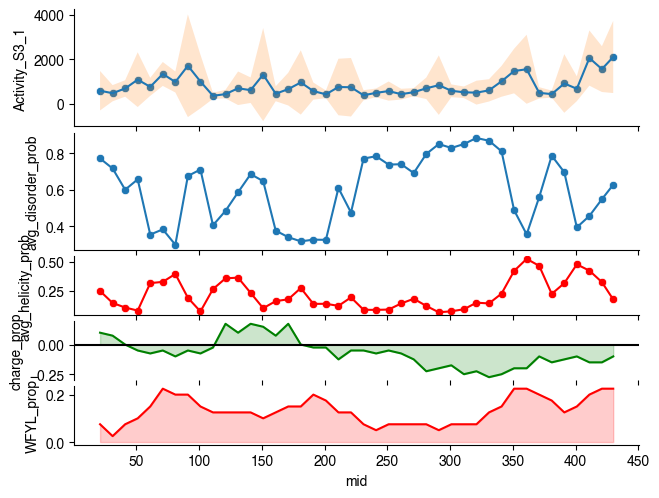

In [83]:
fig, axs = plt.subplots(5, 1, height_ratios = (1,1, 0.5, 0.5, 0.5), sharex = True)

# AD SCORE
sns.lineplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = axs[0])
sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = axs[0])
axs[0].fill_between(BasicArTh["mid"], BasicArTh["activ_err_start"],  BasicArTh["activ_err_end"], alpha=0.2)

# DISORDER -- maybe do full sequence then ax imshow
sns.lineplot(data = BasicArTh, x = "mid", y = "avg_disorder_prob", ax = axs[1])
sns.scatterplot(data = BasicArTh, x = "mid", y = "avg_disorder_prob", ax = axs[1])

# HELICITY
sns.lineplot(data = BasicArTh, x = "mid", y = "avg_helicity_prob", ax = axs[2], color = 'red')
sns.scatterplot(data = BasicArTh, x = "mid", y = "avg_helicity_prob", ax = axs[2], color = 'red')

# CHARGE
sns.lineplot(data = BasicArTh, x = "mid", y = "charge_prop", ax = axs[3], color = 'green')
#sns.scatterplot(data = BasicArTh, x = "mid", y = "charge_prop", ax = axs[3], color = 'red')
axs[3].axhline(0, color = 'black')
axs[3].fill_between(BasicArTh["mid"], 0,  BasicArTh["charge_prop"], alpha=0.2, color = 'green')

# AROMATICS
sns.lineplot(data = BasicArTh, x = "mid", y = "WFYL_prop", ax = axs[4], color = 'red')
#sns.scatterplot(data = BasicArTh, x = "mid", y = "WFYL_prop", ax = axs[4], color = 'red')
axs[4].fill_between(BasicArTh["mid"], 0,  BasicArTh["WFYL_prop"], alpha=0.2, color = 'red')


sns.despine()
sns.despine(ax = axs[3], bottom = True)
plt.tight_layout(pad = 0)


array([3.33921146e-03, 1.95067506e-02, 5.86771406e-02, 9.30581167e-02,
       9.74801257e-02, 1.37645975e-01, 1.44473672e-01, 1.40415907e-01,
       1.43686563e-01, 5.10168254e-01, 5.44983506e-01, 5.67118764e-01,
       6.24166012e-01, 6.38305485e-01, 6.25025749e-01, 6.00571871e-01,
       5.41195512e-01, 4.68378186e-01, 3.85536343e-01, 2.66186029e-01,
       1.92743480e-01, 1.22546867e-01, 6.29706979e-02, 5.59778288e-02,
       1.05331866e-02, 1.59677297e-01, 1.29753962e-01, 1.27490416e-01,
       1.33702695e-01, 1.25929266e-01, 1.00363716e-01, 7.35911354e-02,
       8.97187591e-02, 6.75221207e-03, 2.68275380e-01, 2.84054160e-01,
       2.72087604e-01, 2.04176754e-01, 2.75801606e-02, 9.27692354e-02,
       1.31952107e-01, 1.76896572e-01, 1.45050585e-01, 1.41075119e-01,
       1.38138458e-01, 1.06939398e-01, 7.88625479e-02, 1.87331885e-01,
       2.36601084e-01, 2.43038371e-01, 2.28124037e-01, 2.53920346e-01,
       2.47996405e-01, 2.08836749e-01, 3.89930569e-02, 3.70848626e-02,
      

In [171]:
palette = sns.color_palette('magma_r', 4)
palette

[(0.994738, 0.62435, 0.427397),
 (0.868793, 0.287728, 0.409303),
 (0.550287, 0.161158, 0.505719),
 (0.232077, 0.059889, 0.437695)]

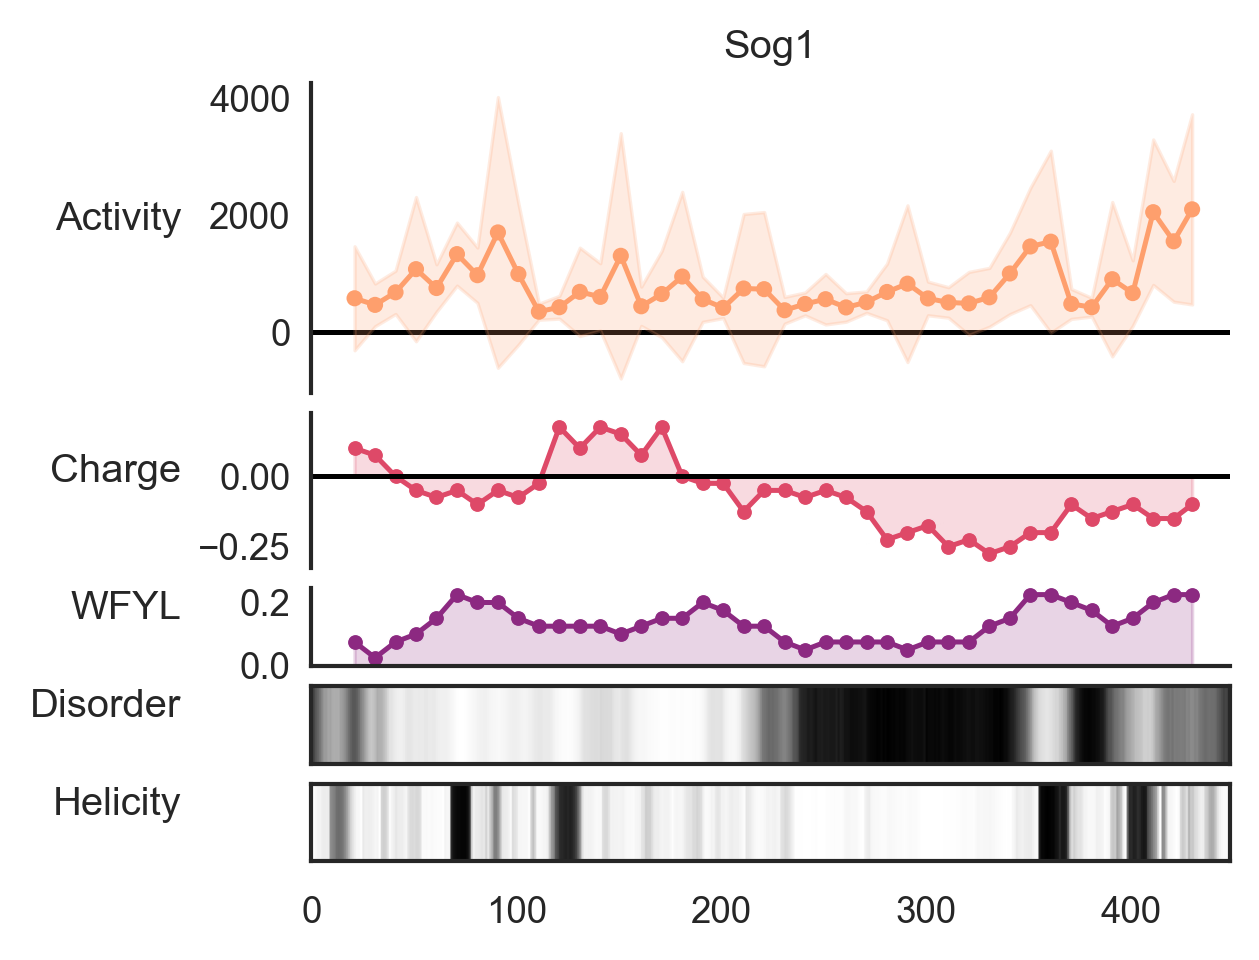

In [207]:
# WITH IMSHOW DISORDER AND HELICITY

sns.set_style('white')
sns.set_context('paper')

fig, axs = plt.subplots(5, 1, height_ratios = (1,0.5, 0.25, 0.25, 0.25), sharex = True, figsize = (4, 3), dpi = 300)

# AD SCORE
axs[0].axhline(0, color = 'black', zorder = 0)
sns.lineplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = axs[0], zorder = 10, color = palette[0])
sns.scatterplot(data = BasicArTh, x = "mid", y = "Activity_S3_1", ax = axs[0], zorder = 20, edgecolor = 'none', s = 15, color = palette[0])
axs[0].fill_between(BasicArTh["mid"], BasicArTh["activ_err_start"],  BasicArTh["activ_err_end"], alpha=0.2, zorder = 5, color = palette[0])
sns.despine(ax = axs[0], bottom = True)
axs[0].set_ylabel("Activity", rotation = 0, ha = 'right')

# CHARGE
sns.lineplot(data = BasicArTh, x = "mid", y = "charge_prop", ax = axs[1], color = palette[1])
sns.scatterplot(data = BasicArTh, x = "mid", y = "charge_prop", ax = axs[1], color = palette[1], s = 15)
axs[1].axhline(0, color = 'black')
axs[1].fill_between(BasicArTh["mid"], 0,  BasicArTh["charge_prop"], alpha=0.2, color = palette[1])
axs[1].set_ylabel("Charge", rotation = 0, ha = 'right')
axs[1].set_ylim(min(BasicArTh["charge_prop"]) - 0.05, max(BasicArTh[ "charge_prop"]) + 0.05)


# AROMATICS
sns.lineplot(data = BasicArTh, x = "mid", y = "WFYL_prop", ax = axs[2], color = palette[2])
sns.scatterplot(data = BasicArTh, x = "mid", y = "WFYL_prop", ax = axs[2], color = palette[2], s = 15)
axs[2].set_ylim(0, max(BasicArTh[ "WFYL_prop"]) + 0.02)
axs[2].fill_between(BasicArTh["mid"], 0,  BasicArTh["WFYL_prop"], alpha=0.2, color = palette[2])
sns.despine(ax = axs[2])
axs[2].set_ylabel("WFYL", rotation = 0, ha = 'right')


# DISORDER -- maybe do full sequence then ax imshow
axs[3].imshow(pd.DataFrame(meta.predict_disorder(wt_seq)).T, cmap='Grays', aspect='auto')
axs[3].set_ylabel("Disorder", rotation = 0, ha = 'right')
axs[3].set_yticks([])

# HELICITY
axs[4].imshow(pd.DataFrame(Protein(wt_seq).predictor.dssp_helicity(mode = 'probability')).T, cmap='Grays', aspect='auto')
axs[4].set_ylabel("Helicity", rotation = 0, ha = 'right')
axs[4].set_yticks([])


axs[0].tick_params(axis='y', pad=0)
axs[1].tick_params(axis='y', pad=0)
axs[2].tick_params(axis='y', pad=0)

axs[0].set_title("Sog1")
sns.despine(ax = axs[1], bottom = True)
fig.align_ylabels()
plt.tight_layout(pad = 0)
plt.savefig("../output/figures/wt_summaries/" + "Sog1", bbox_inches='tight')


# 2. Repeat with orthologs

In [241]:
ortholog_seqs = pd.read_csv("../data/sog1_orthologs.csv", sep = "\t")
ortholog_seqs = ortholog_seqs.rename(columns = {"Wild type sequences:" : "Other", "Unnamed: 1" : "ProteinSeq"})
ortholog_seqs["merge_name"] = ortholog_seqs["Other"].str.split("_").str[0].str.replace("SOG1", "").str.strip()
ortholog_seqs

,Other,ProteinSeq,merge_name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [243]:
ortholog_name_mapping = pd.read_csv("../output/ortholog_name_mapping.csv")
ortholog_name_mapping["merge_name"] = ortholog_name_mapping["Other"].str.split("_").str[0].str.replace("SOG1", "").str.strip()
ortholog_name_mapping = pd.merge(ortholog_name_mapping, ortholog_seqs, how = 'left', on = 'merge_name')
ortholog_name_mapping.at[15, "ProteinSeq"] = wt_seq
ortholog_name_mapping

,Unnamed: 0,Other_x,Description_name,standard_name,name,merge_name,Other_y,ProteinSeq
0,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...
1,567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor,S.bicolor,S.bicolor,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...
2,687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr,E.grandis,E.grandis,E.grandis,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...
3,779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi,V.vinifera,V.vinifera,V.vinifera peptide,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...
4,867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr,P.trichocarpa,PopulusTrichocarpa,PopulusTrichocarpa,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...
5,961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa,N.tabacum,Nicotianatabacum(tobacco),Nicotianatabacum(tobacco),Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...
6,1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa,G.max,G.max,G.max,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...
7,1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo,S.moellendorffii,Selaginellamoellendorffii(spikemoss),Selaginellamoellendorffii(spikemoss),Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...
8,1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo,M.polymorpha,MarchantiaPolymorpha,MarchantiaPolymorpha,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...
9,1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa,P.patens,PhyscomitriumPatens,PhyscomitriumPatens,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...


In [250]:
# Reading in the wt tiles of all sog1 orthologs and nac family tiles
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles["name"] = basic_tiles["name"].str.split(" ").str[0]
ortholog_tiles = pd.merge(basic_tiles,ortholog_name_mapping, on = 'name' )
ortholog_tiles["mid"] = (ortholog_tiles["Start"].astype(int) + ortholog_tiles["End"].astype(int)) / 2
ortholog_tiles

,Start,End,Description,Other,tile,Unnamed: 0_x,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,Unnamed: 0_y,Other_x,Description_name,standard_name,merge_name,Other_y,ProteinSeq,mid
0,1,40,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,20.5
1,11,50,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,30.5
2,21,60,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,40.5
3,31,70,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,50.5
4,41,80,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,60.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,390.5
647,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,400.5
648,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,410.5
649,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,2975,Q6NQK2,BasicArTh,A.thaliana,Q6NQK2,NaN,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVI...,420.5


In [251]:
# CHARGE
ortholog_tiles["charge_prop"] = ortholog_tiles["tile"].str.count("R") + ortholog_tiles["tile"].str.count("K") - ortholog_tiles["tile"].str.count("D") - ortholog_tiles["tile"].str.count("E")
ortholog_tiles["charge_prop"] = ortholog_tiles["charge_prop"]/40

# AROMATICS
ortholog_tiles["WFYL_prop"] = ortholog_tiles["tile"].str.count("W") + ortholog_tiles["tile"].str.count("F") + ortholog_tiles["tile"].str.count("Y") + ortholog_tiles["tile"].str.count("L")
ortholog_tiles["WFYL_prop"] = ortholog_tiles["WFYL_prop"] / 40
ortholog_tiles.head(3)

,Start,End,Description,Other,tile,Unnamed: 0_x,Activity_S3_1,Error,BC Count,activ_err_start,...,Unnamed: 0_y,Other_x,Description_name,standard_name,merge_name,Other_y,ProteinSeq,mid,charge_prop,WFYL_prop
0,1,40,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,...,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,20.5,0.075,0.100
1,11,50,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,...,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,30.5,-0.025,0.050
2,21,60,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,...,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,40.5,-0.050,0.075


In [262]:
def plot_fig(standard_name): # WITH IMSHOW DISORDER AND HELICITY

    sns.set_style('white')
    sns.set_context('paper')

    fig, axs = plt.subplots(5, 1, height_ratios = (1,0.5, 0.25, 0.25, 0.25), sharex = True, figsize = (4, 3), dpi = 300)

    df = ortholog_tiles[ortholog_tiles["standard_name"] == standard_name]
    #display(df)

    # AD SCORE
    axs[0].axhline(0, color = 'black', zorder = 0)
    sns.lineplot(data = df, x = "mid", y = "Activity_S3_1", ax = axs[0], zorder = 10, color = palette[0])
    sns.scatterplot(data = df, x = "mid", y = "Activity_S3_1", ax = axs[0], zorder = 20, edgecolor = 'none', s = 15, color = palette[0])
    axs[0].fill_between(df["mid"], df["activ_err_start"],  df["activ_err_end"], alpha=0.2, zorder = 5, color = palette[0])
    sns.despine(ax = axs[0], bottom = True)
    axs[0].set_ylabel("Activity", rotation = 0, ha = 'right')

    # CHARGE
    sns.lineplot(data = df, x = "mid", y = "charge_prop", ax = axs[1], color = palette[1])
    sns.scatterplot(data = df, x = "mid", y = "charge_prop", ax = axs[1], color = palette[1], s = 15)
    axs[1].axhline(0, color = 'black')
    axs[1].fill_between(df["mid"], 0,  df["charge_prop"], alpha=0.2, color = palette[1])
    axs[1].set_ylabel("Charge", rotation = 0, ha = 'right')
    axs[1].set_ylim(min(df["charge_prop"]) - 0.05, max(df[ "charge_prop"]) + 0.05)


    # AROMATICS
    sns.lineplot(data = df, x = "mid", y = "WFYL_prop", ax = axs[2], color = palette[2])
    sns.scatterplot(data = df, x = "mid", y = "WFYL_prop", ax = axs[2], color = palette[2], s = 15)
    axs[2].set_ylim(0, max(df[ "WFYL_prop"]) + 0.02)
    axs[2].fill_between(df["mid"], 0,  df["WFYL_prop"], alpha=0.2, color = palette[2])
    sns.despine(ax = axs[2])
    axs[2].set_ylabel("WFYL", rotation = 0, ha = 'right')

    wt_seq = df["ProteinSeq"].iloc[0]

    # DISORDER -- maybe do full sequence then ax imshow
    axs[3].imshow(pd.DataFrame(meta.predict_disorder(wt_seq)).T, cmap='Grays', aspect='auto')
    axs[3].set_ylabel("Disorder", rotation = 0, ha = 'right')
    axs[3].set_yticks([])

    # HELICITY
    axs[4].imshow(pd.DataFrame(Protein(wt_seq).predictor.dssp_helicity(mode = 'probability')).T, cmap='Grays', aspect='auto')
    axs[4].set_ylabel("Helicity", rotation = 0, ha = 'right')
    axs[4].set_yticks([])


    axs[0].tick_params(axis='y', pad=0)
    axs[1].tick_params(axis='y', pad=0)
    axs[2].tick_params(axis='y', pad=0)

    axs[0].set_title(standard_name)
    sns.despine(ax = axs[1], bottom = True)
    fig.align_ylabels()
    plt.tight_layout(pad = 0)
    plt.savefig("../output/figures/wt_summaries/" + standard_name + ".png", bbox_inches='tight')


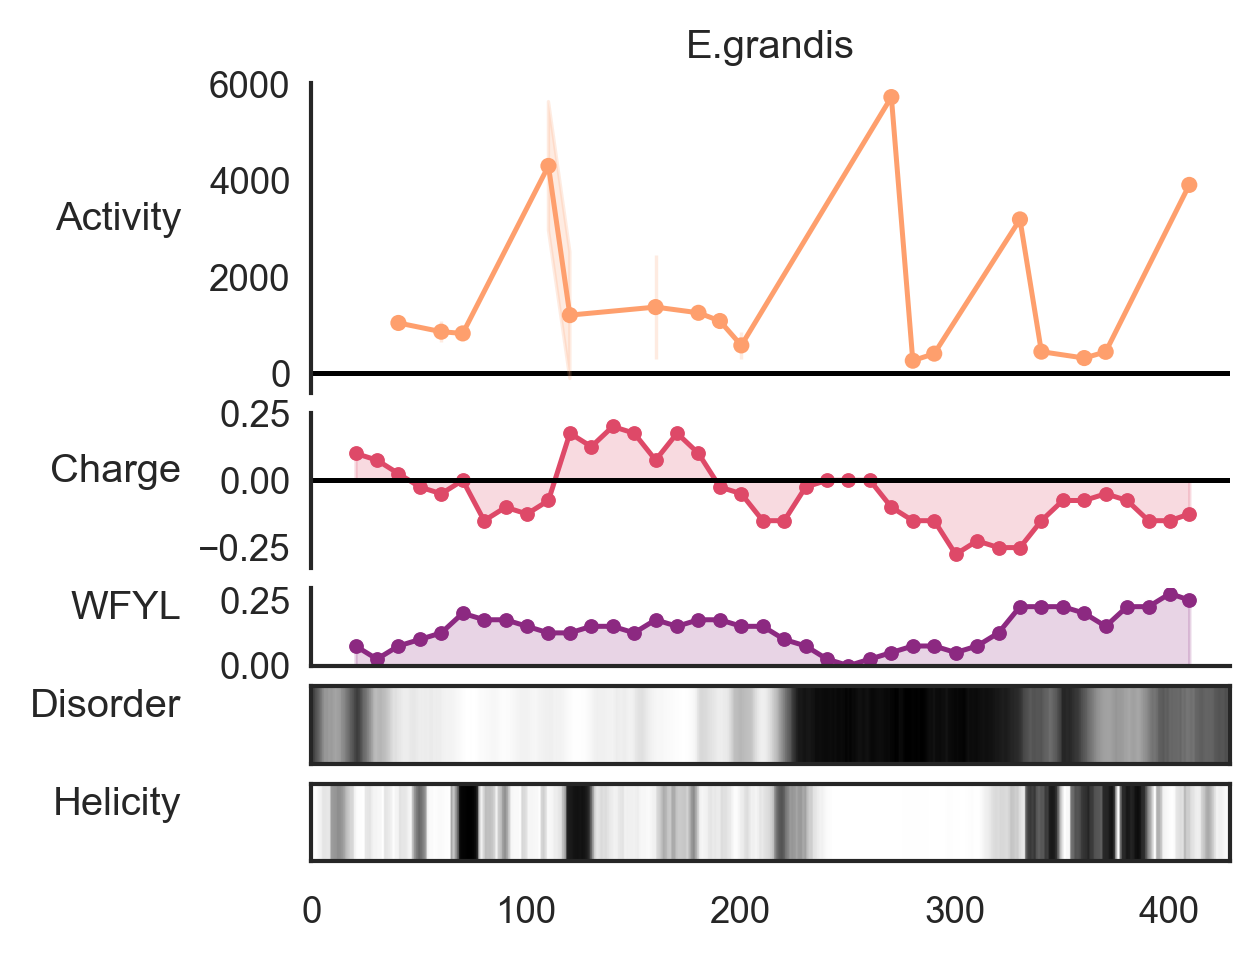

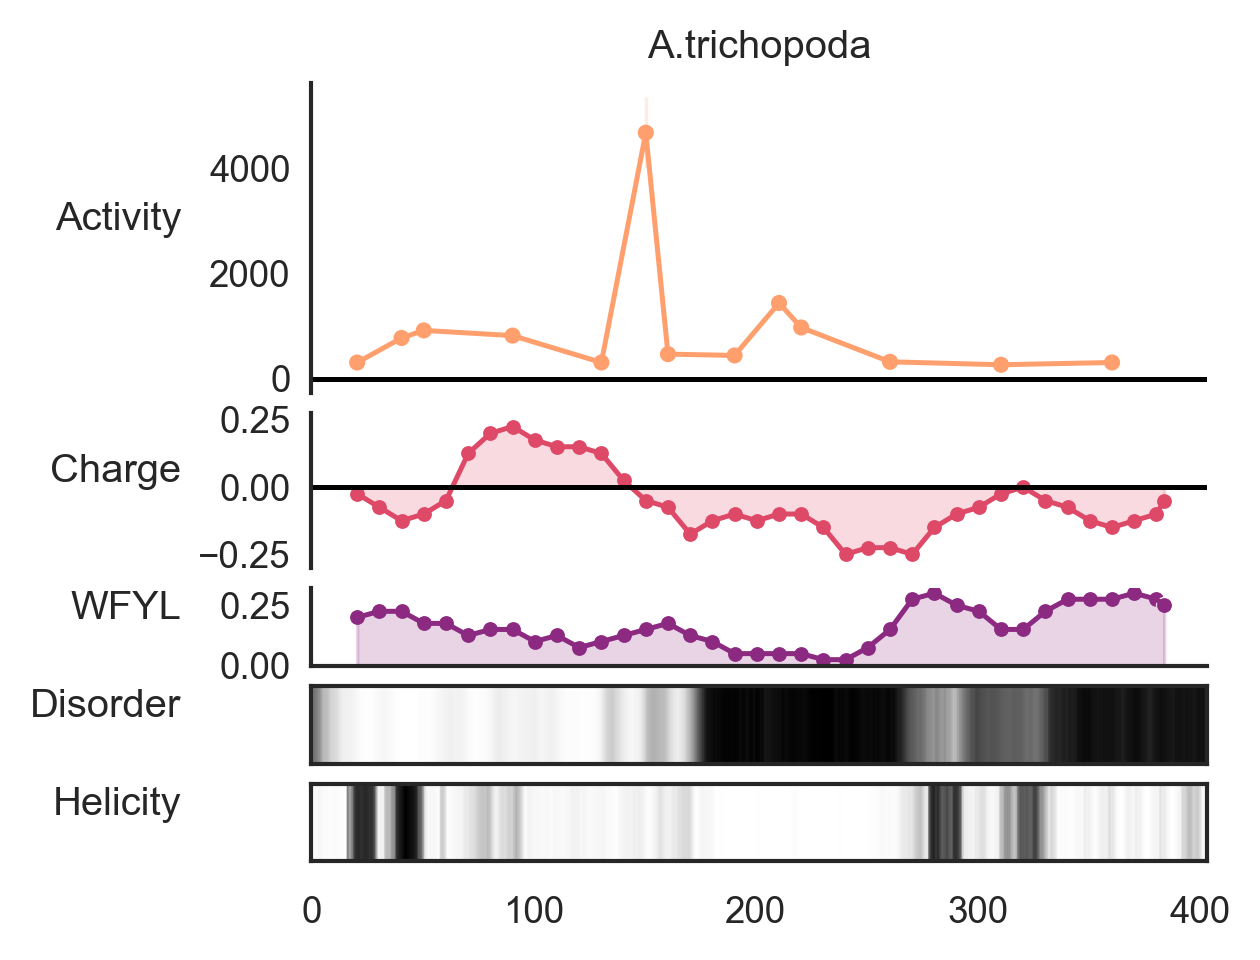

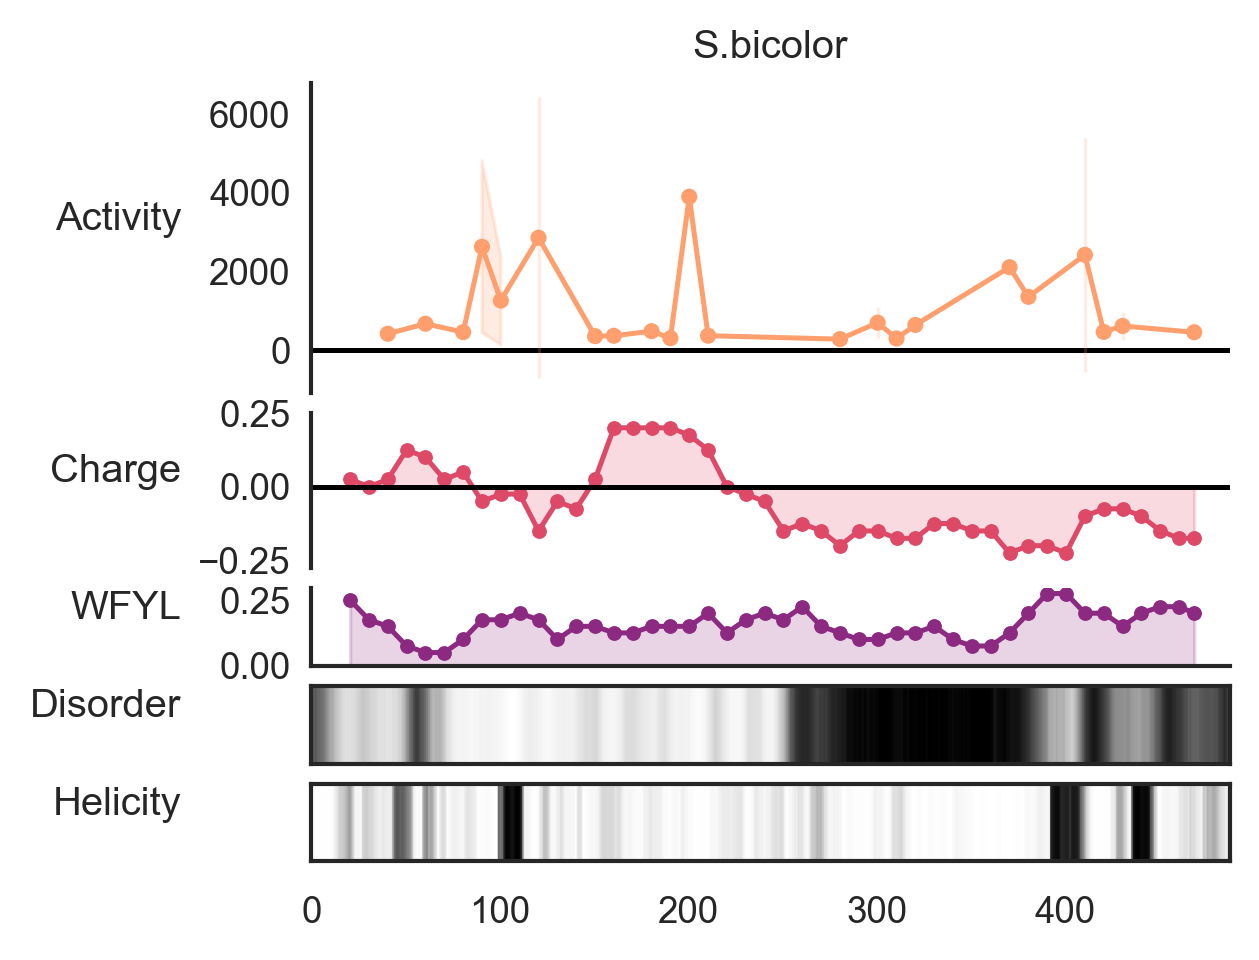

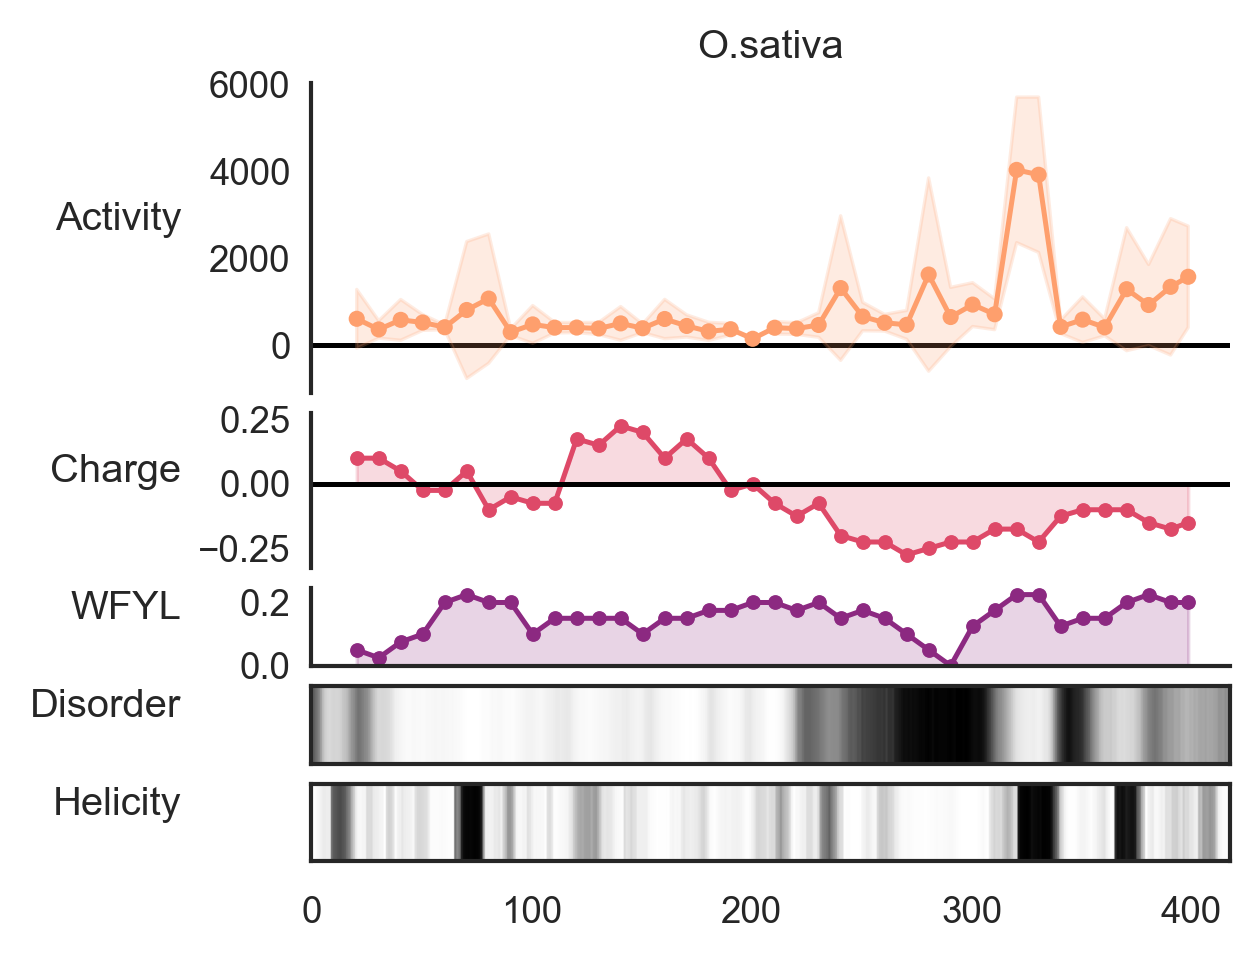

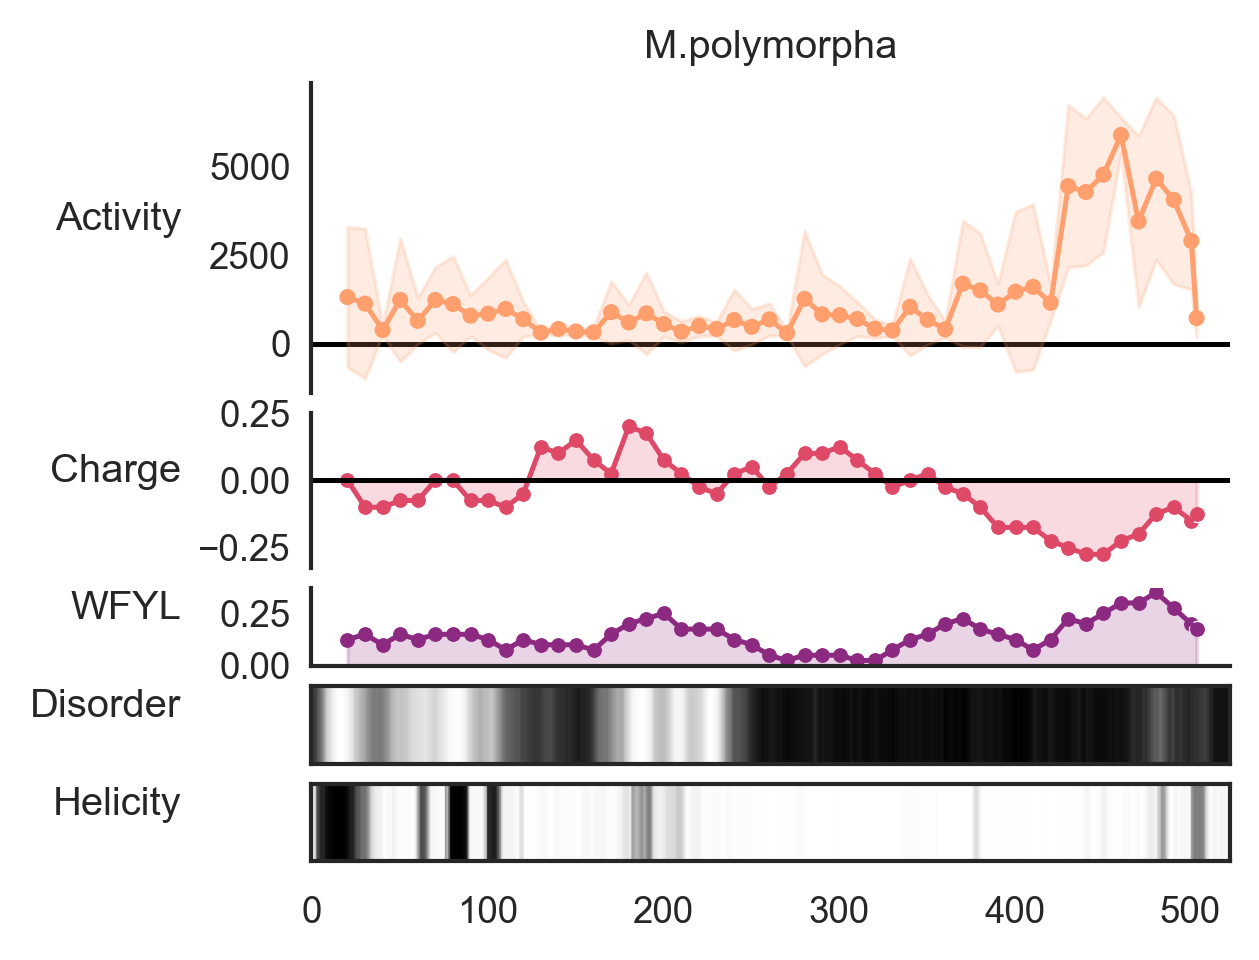

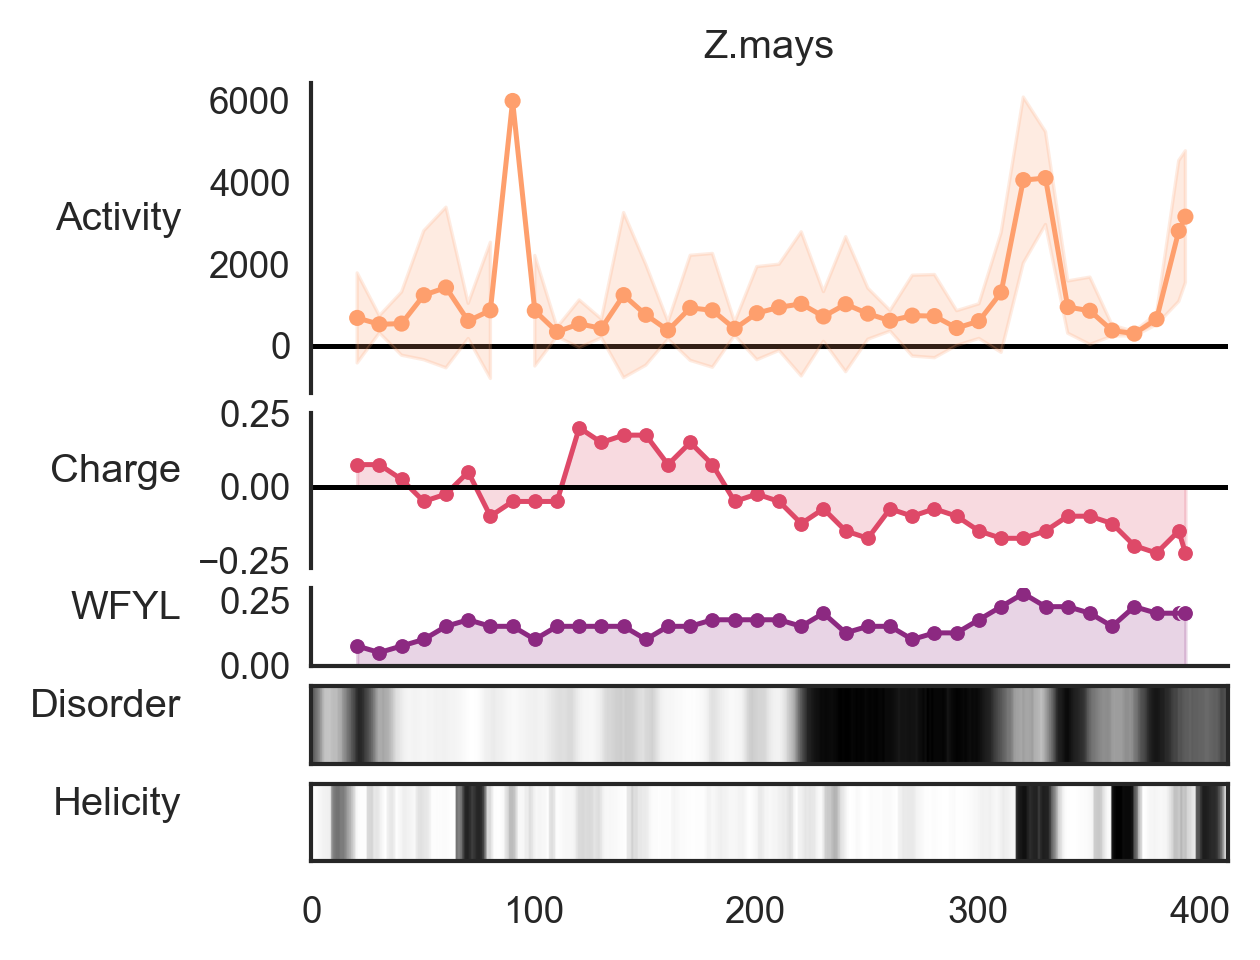

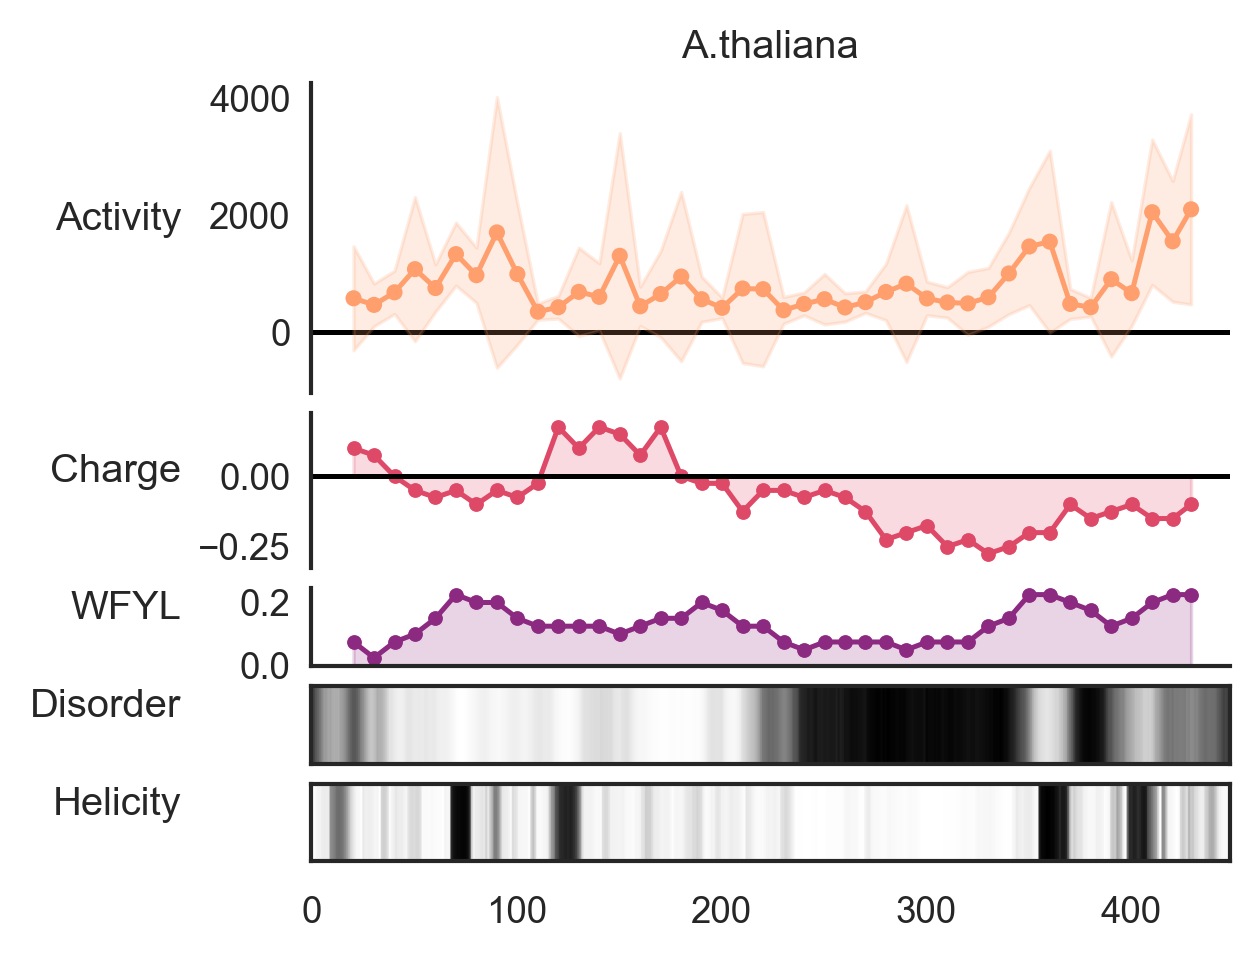

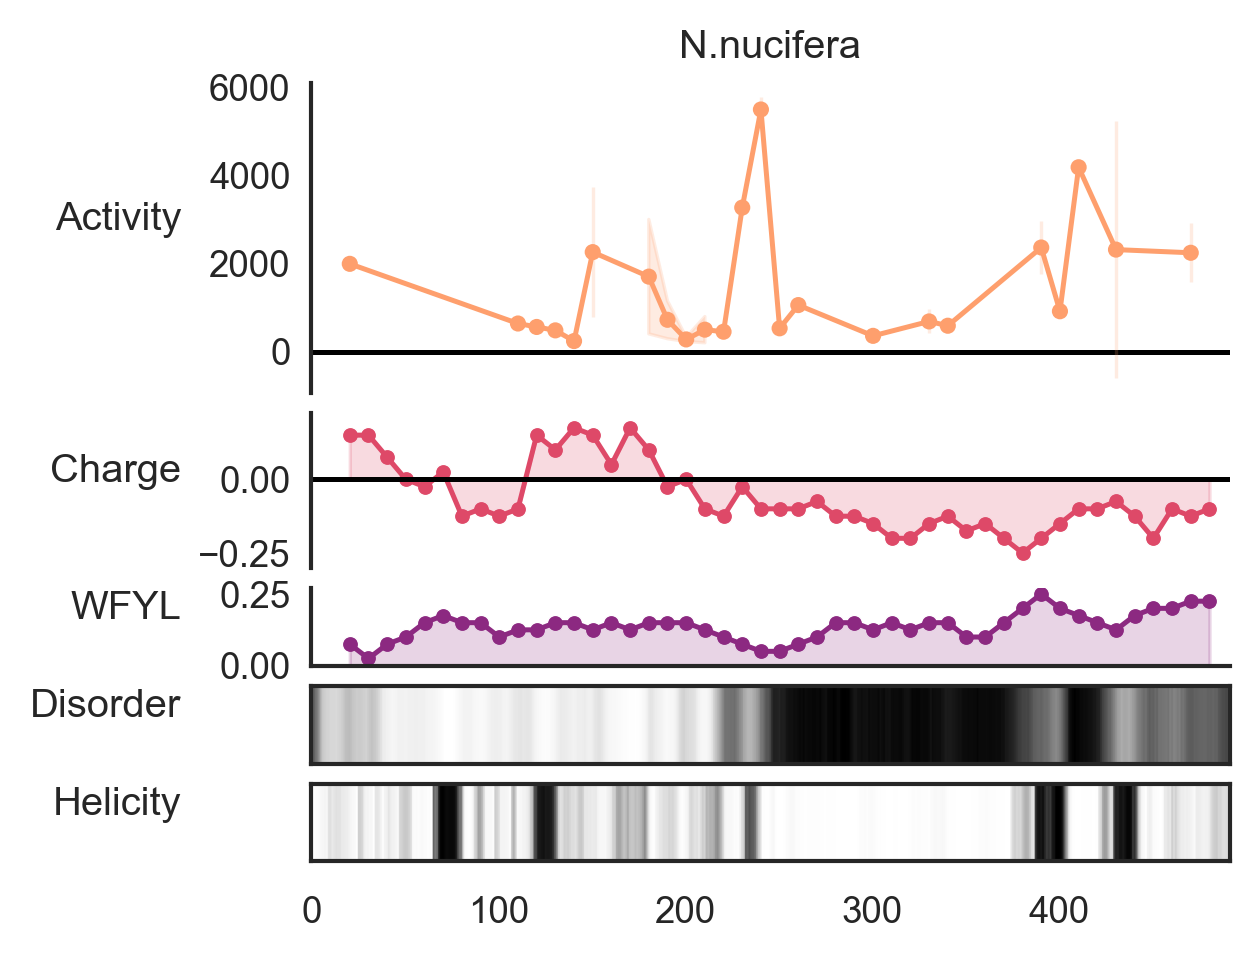

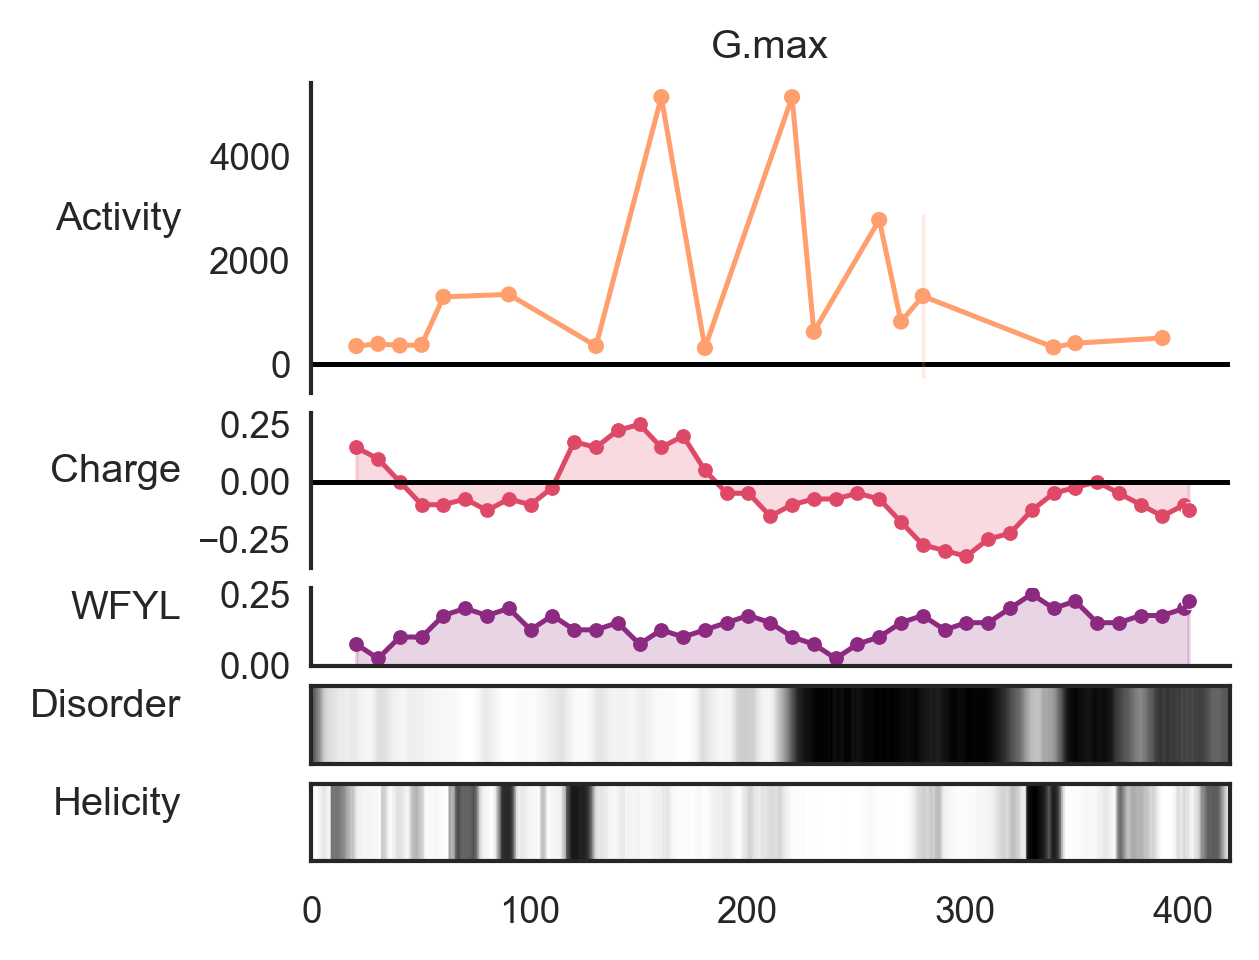

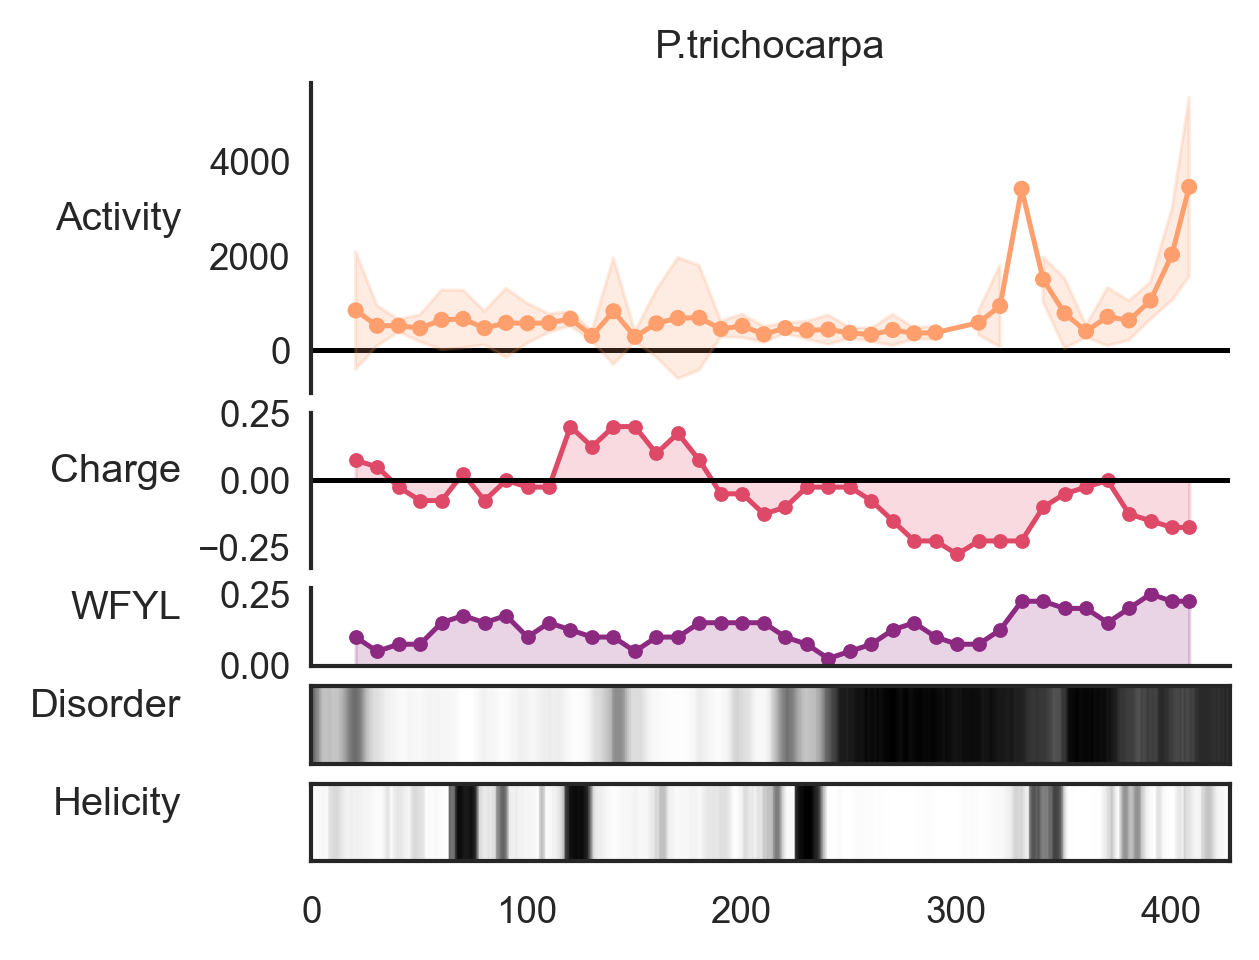

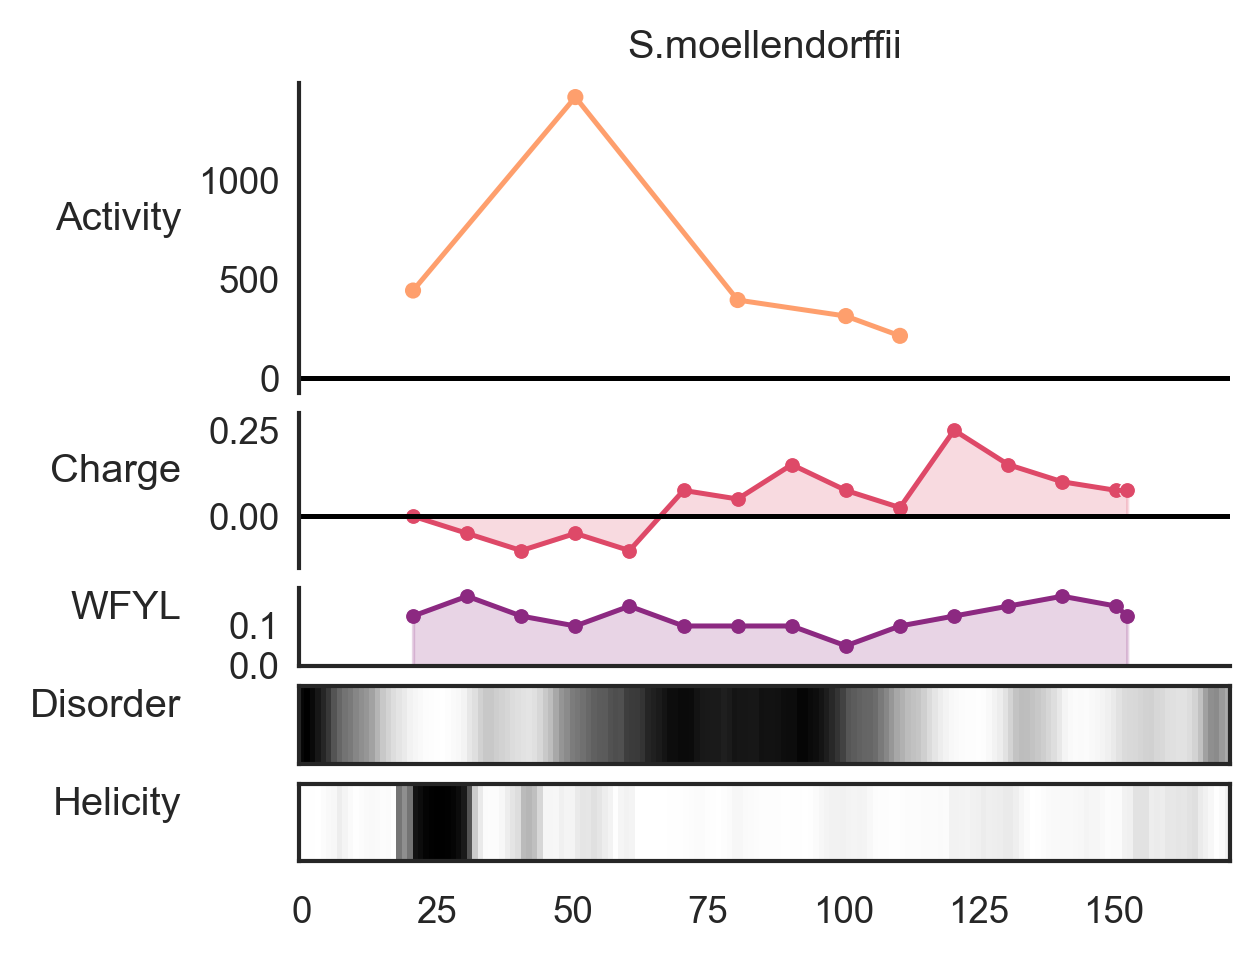

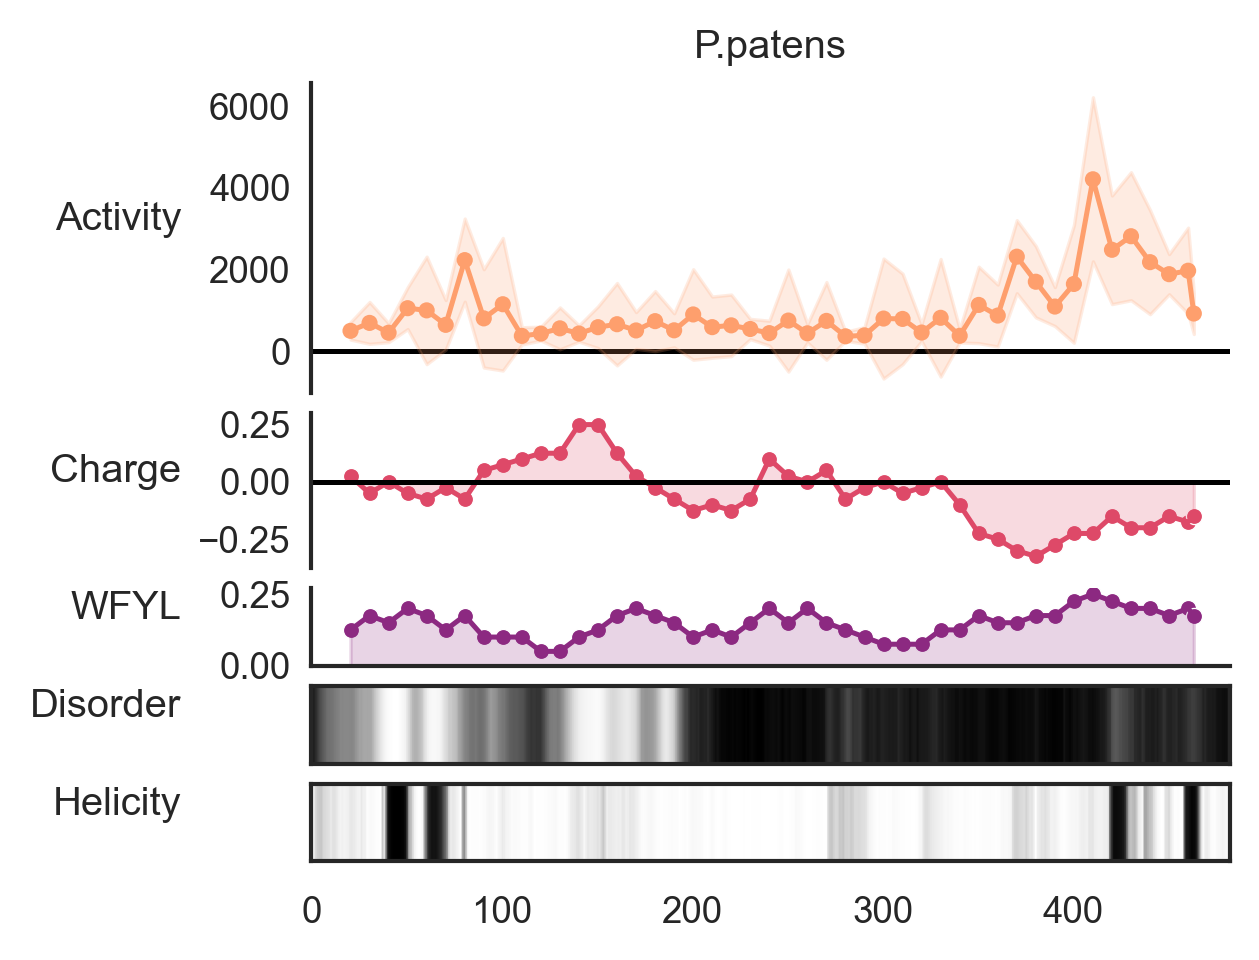

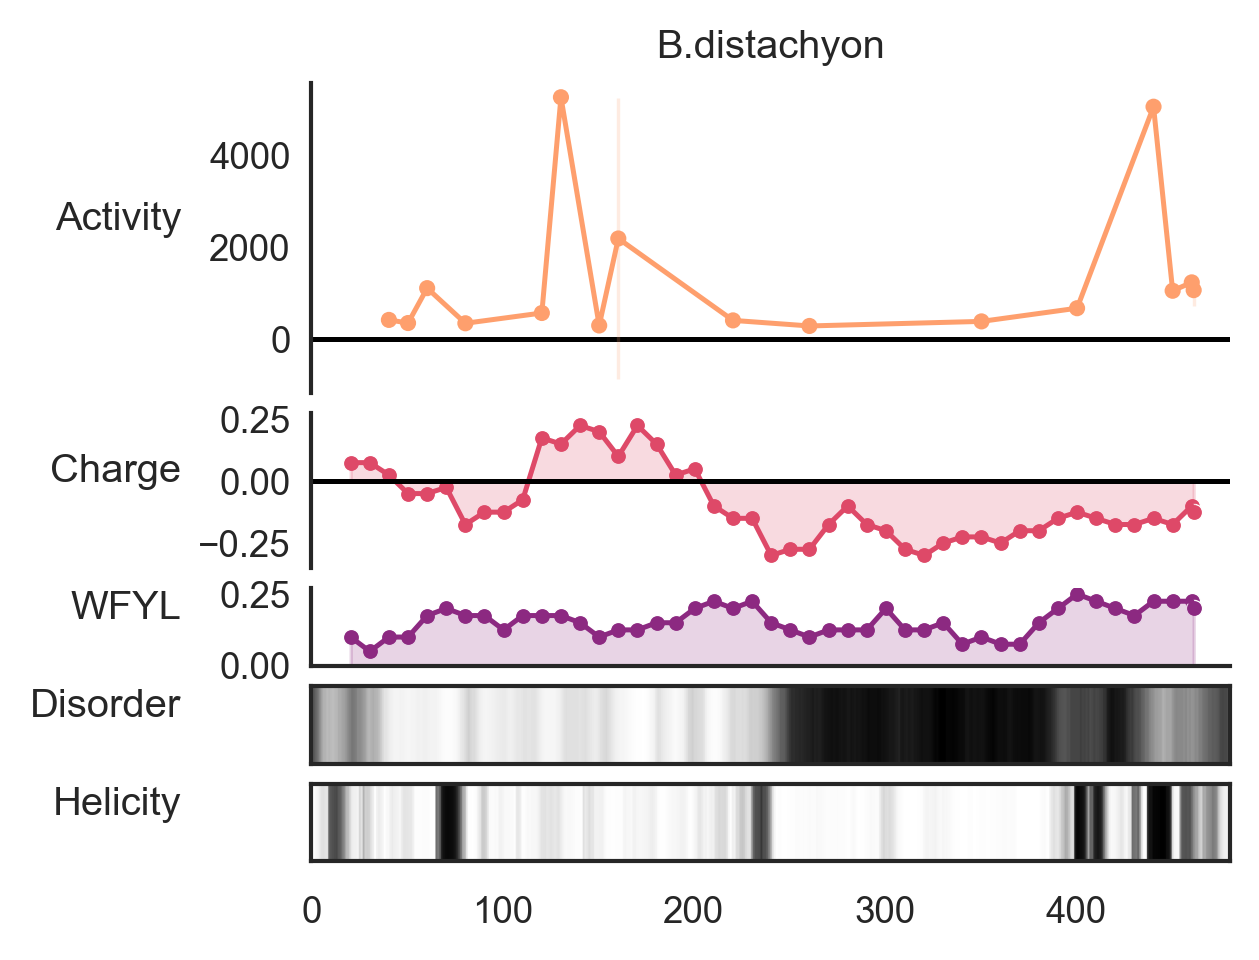

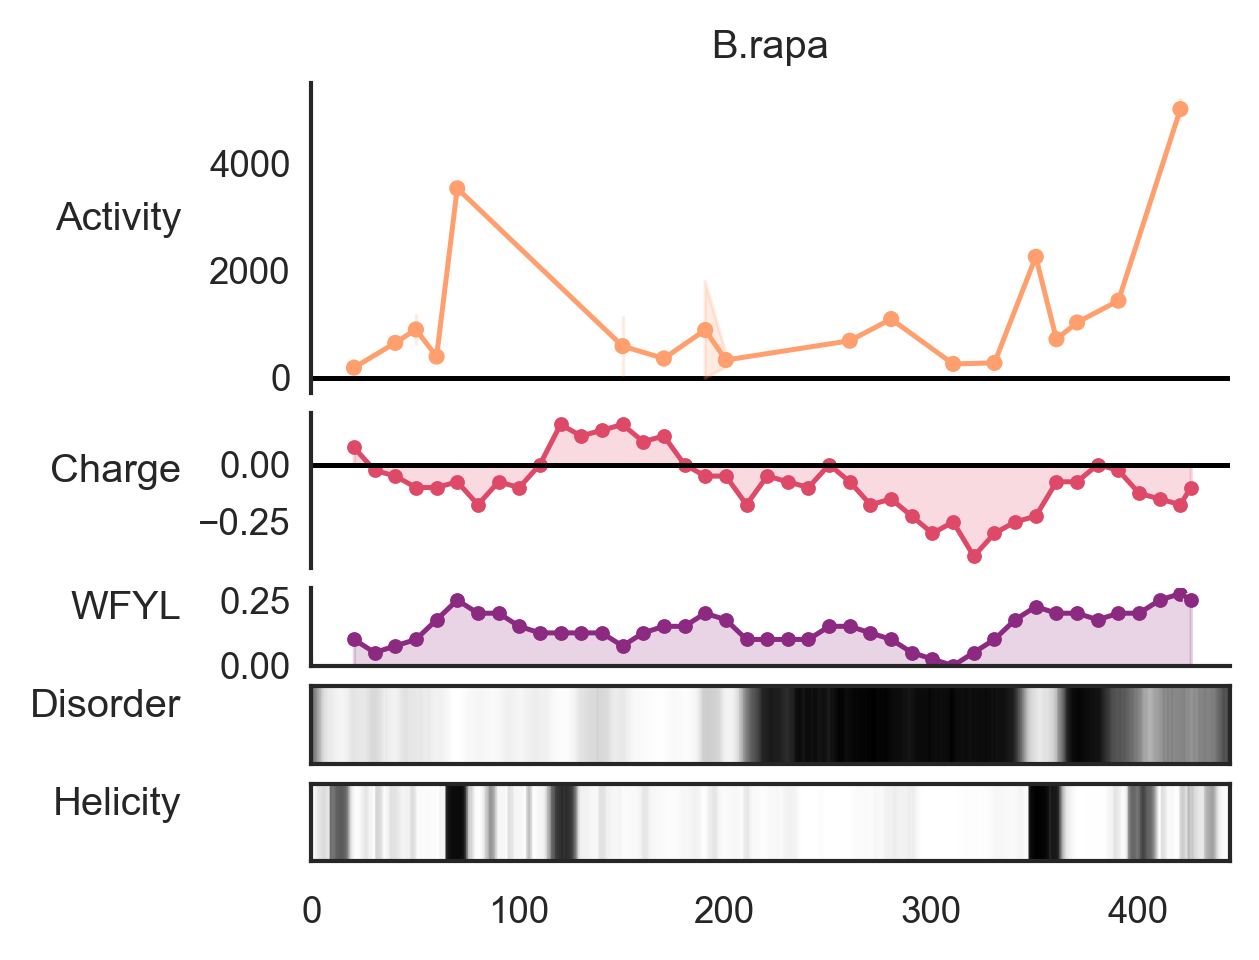

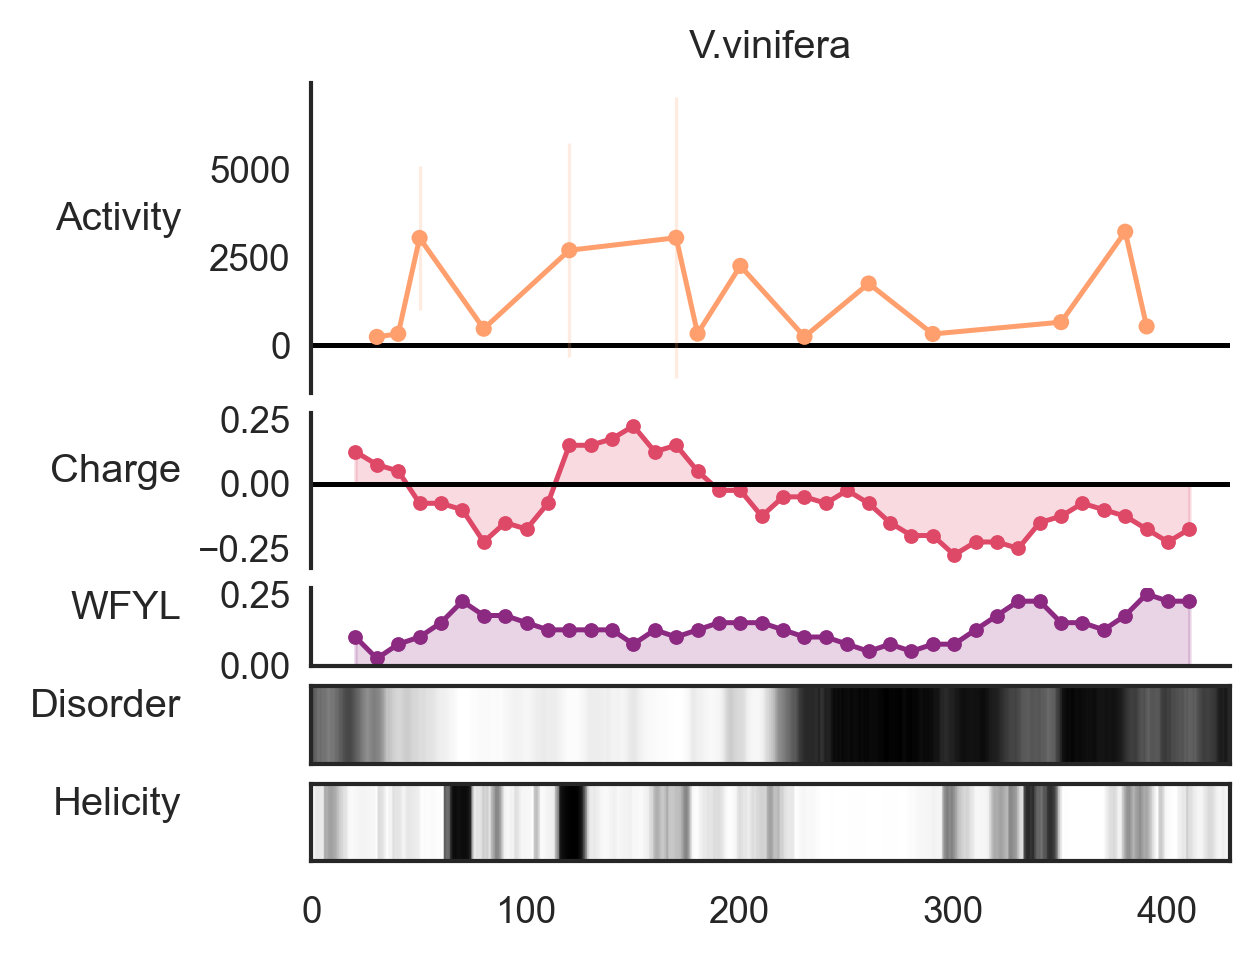

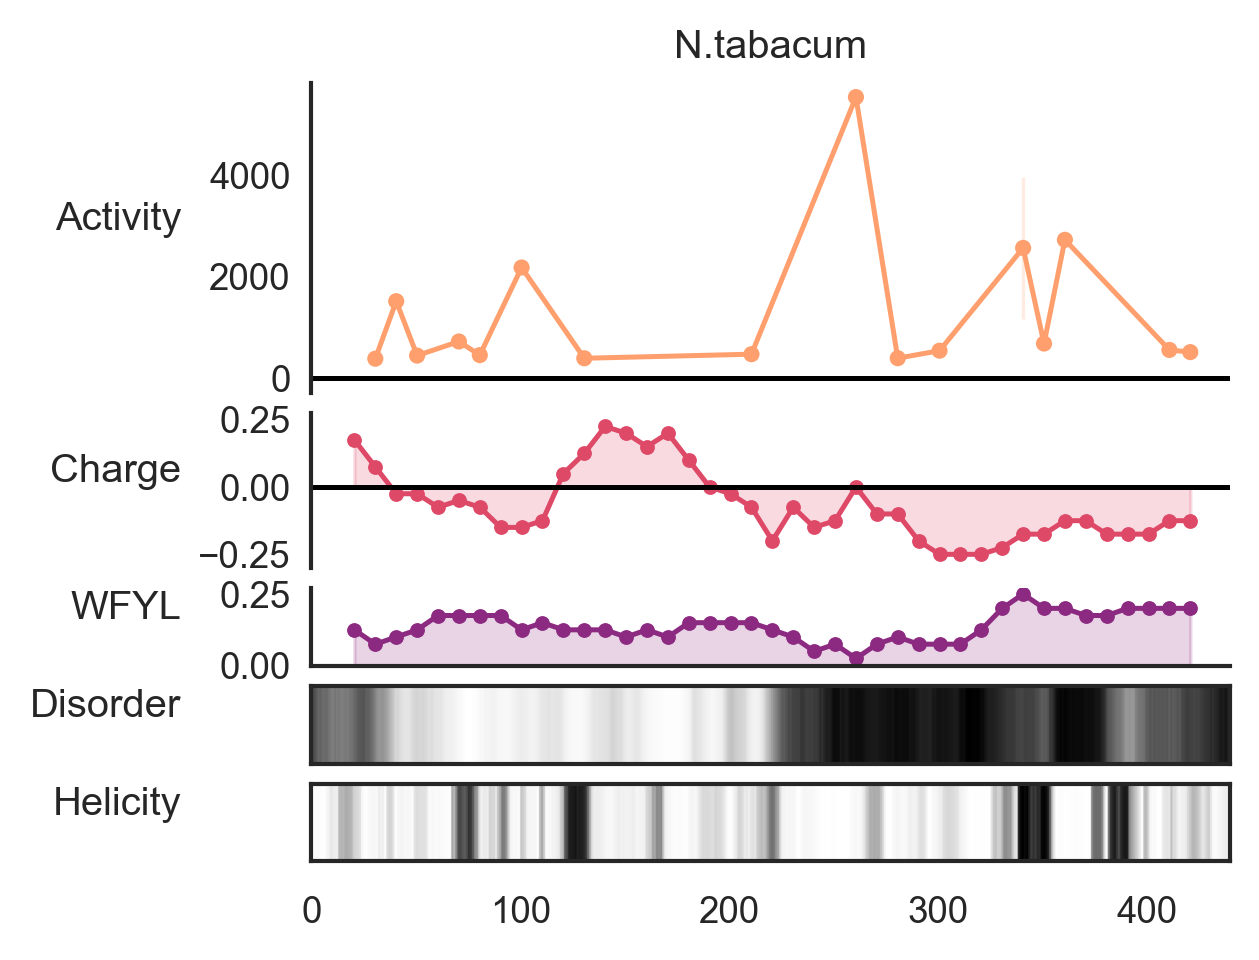

In [263]:
for standard_name in set(ortholog_tiles["standard_name"]):
    plot_fig(standard_name)

# 3. Repeat with NAC Family

In [265]:
# Reading in full sequences
nac_seqs = pd.read_csv("../data/nac_family.csv", sep = "\t", header = None)
nac_seqs["name"] = "NAC" + nac_seqs[0].str.split("|").str[0]
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles["search_term"] = basic_tiles["Description"].str.split(".").str[0] + "\."
nac_seqs["uniprotID"] = nac_seqs[0].str.split("|").str[1]
nac_seqs = pd.merge(nac_seqs, basic_tiles[["Other", "search_term"]].drop_duplicates(), left_on = "uniprotID", right_on = "Other")
nac_seqs

,0,1,name,uniprotID,Other,search_term
0,006|Q9LR74|,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWL...,NAC006,Q9LR74,Q9LR74,Basic6\.
1,012|Q9LPI7|,MADNKVNLSINGQSKVPPGFRFHPTEEELLHYYLRKKVNSQKIDLD...,NAC012,Q9LPI7,Q9LPI7,Basic12\.
2,016|A4FVP|,MVDSSRDSCFKAGKFSAPGFRFHPTDEELVVYYLKRKICCKKLRVN...,NAC016,A4FVP,A4FVP,Basic16\.
3,019|Q9C932|,MGIQETDPLTQLSLPPGFRFYPTDEELMVQYLCRKAAGYDFSLQLI...,NAC019,Q9C932,Q9C932,Basic19\.
4,042|Q9SK55|JUNGBRUNNEN|,MSGEGNLGKDHEEENEAPLPGFRFHPTDEELLGYYLRRKVENKTIK...,NAC042,Q9SK55,Q9SK55,Basic42\.
5,044|F4J4R5|,MARAWIVDGRGIAAKVKNASLSSALQIQDCGAHIKCPNCTYRIDNS...,NAC044,F4J4R5,F4J4R5,Basic44\.
6,062|Q9SCK6|,MNQNLHVLSMDSLPVGLRFRPTDEELIRYYLRRKINGHDDDVKAIR...,NAC062,Q9SCK6,Q9SCK6,Basic62\.
7,067|O82593|,MMKDPTGYRFSPTGEEVINHYLKNKILGKTWLVDEAISEINILNHK...,NAC067,O82593,O82593,Basic67\.
8,071|O49697|,MGSSCLPPGFRFHPTDEELIGYYLSRKIEGLEIELEVIPVIDLYKF...,NAC071,O49697,O49697,Basic71\.
9,076|O65508|,MESVDQSCSVPPGFRFHPTDEELVGYYLRKKVASQKIDLDVIRDID...,NAC076,O65508,O65508,Basic76\.


In [295]:
activity_dict = {}
for i in nac_seqs.index:
    activities = sog1_helpers.return_activities(nac_seqs["search_term"].iloc[i], pos_regex = r'\.(\d+)')
    activities = activities[~activities["Description"].str.contains("Psv")]
    activities = activities[~activities["Description"].str.contains("PSv")]
    # CHARGE
    activities["charge_prop"] = activities["tile"].str.count("R") + activities["tile"].str.count("K") - activities["tile"].str.count("D") - activities["tile"].str.count("E")
    activities["charge_prop"] = activities["charge_prop"]/40

    # AROMATICS
    activities["WFYL_prop"] = activities["tile"].str.count("W") + activities["tile"].str.count("F") + activities["tile"].str.count("Y") + activities["tile"].str.count("L")
    activities["WFYL_prop"] = activities["WFYL_prop"] / 40
    activity_dict[nac_seqs["name"].iloc[i]] = activities

In [299]:
def plot_nac_fig(nac_name): # WITH IMSHOW DISORDER AND HELICITY

    sns.set_style('white')
    sns.set_context('paper')

    fig, axs = plt.subplots(5, 1, height_ratios = (1,0.5, 0.25, 0.25, 0.25), sharex = True, figsize = (4, 3), dpi = 300)

    df = activity_dict[nac_name]
    #display(df)

    # AD SCORE
    axs[0].axhline(0, color = 'black', zorder = 0)
    sns.lineplot(data = df, x = "mid", y = "Activity_S3_1", ax = axs[0], zorder = 10, color = palette[0])
    sns.scatterplot(data = df, x = "mid", y = "Activity_S3_1", ax = axs[0], zorder = 20, edgecolor = 'none', s = 15, color = palette[0])
    axs[0].fill_between(df["mid"], df["activ_err_start"],  df["activ_err_end"], alpha=0.2, zorder = 5, color = palette[0])
    sns.despine(ax = axs[0], bottom = True)
    axs[0].set_ylabel("Activity", rotation = 0, ha = 'right')

    # CHARGE
    sns.lineplot(data = df, x = "mid", y = "charge_prop", ax = axs[1], color = palette[1])
    sns.scatterplot(data = df, x = "mid", y = "charge_prop", ax = axs[1], color = palette[1], s = 15)
    axs[1].axhline(0, color = 'black')
    axs[1].fill_between(df["mid"], 0,  df["charge_prop"], alpha=0.2, color = palette[1])
    axs[1].set_ylabel("Charge", rotation = 0, ha = 'right')
    axs[1].set_ylim(min(df["charge_prop"]) - 0.05, max(df[ "charge_prop"]) + 0.05)


    # AROMATICS
    sns.lineplot(data = df, x = "mid", y = "WFYL_prop", ax = axs[2], color = palette[2])
    sns.scatterplot(data = df, x = "mid", y = "WFYL_prop", ax = axs[2], color = palette[2], s = 15)
    axs[2].set_ylim(0, max(df[ "WFYL_prop"]) + 0.02)
    axs[2].fill_between(df["mid"], 0,  df["WFYL_prop"], alpha=0.2, color = palette[2])
    sns.despine(ax = axs[2])
    axs[2].set_ylabel("WFYL", rotation = 0, ha = 'right')

    wt_seq = nac_seqs[nac_seqs["name"] == nac_name][1].iloc[0]

    # DISORDER -- maybe do full sequence then ax imshow
    axs[3].imshow(pd.DataFrame(meta.predict_disorder(wt_seq)).T, cmap='Grays', aspect='auto')
    axs[3].set_ylabel("Disorder", rotation = 0, ha = 'right')
    axs[3].set_yticks([])

    # HELICITY
    axs[4].imshow(pd.DataFrame(Protein(wt_seq).predictor.dssp_helicity(mode = 'probability')).T, cmap='Grays', aspect='auto')
    axs[4].set_ylabel("Helicity", rotation = 0, ha = 'right')
    axs[4].set_yticks([])


    axs[0].tick_params(axis='y', pad=0)
    axs[1].tick_params(axis='y', pad=0)
    axs[2].tick_params(axis='y', pad=0)

    axs[0].set_title(nac_name)
    sns.despine(ax = axs[1], bottom = True)
    fig.align_ylabels()
    plt.tight_layout(pad = 0)
    plt.savefig("../output/figures/wt_summaries/" + nac_name + ".png", bbox_inches='tight')


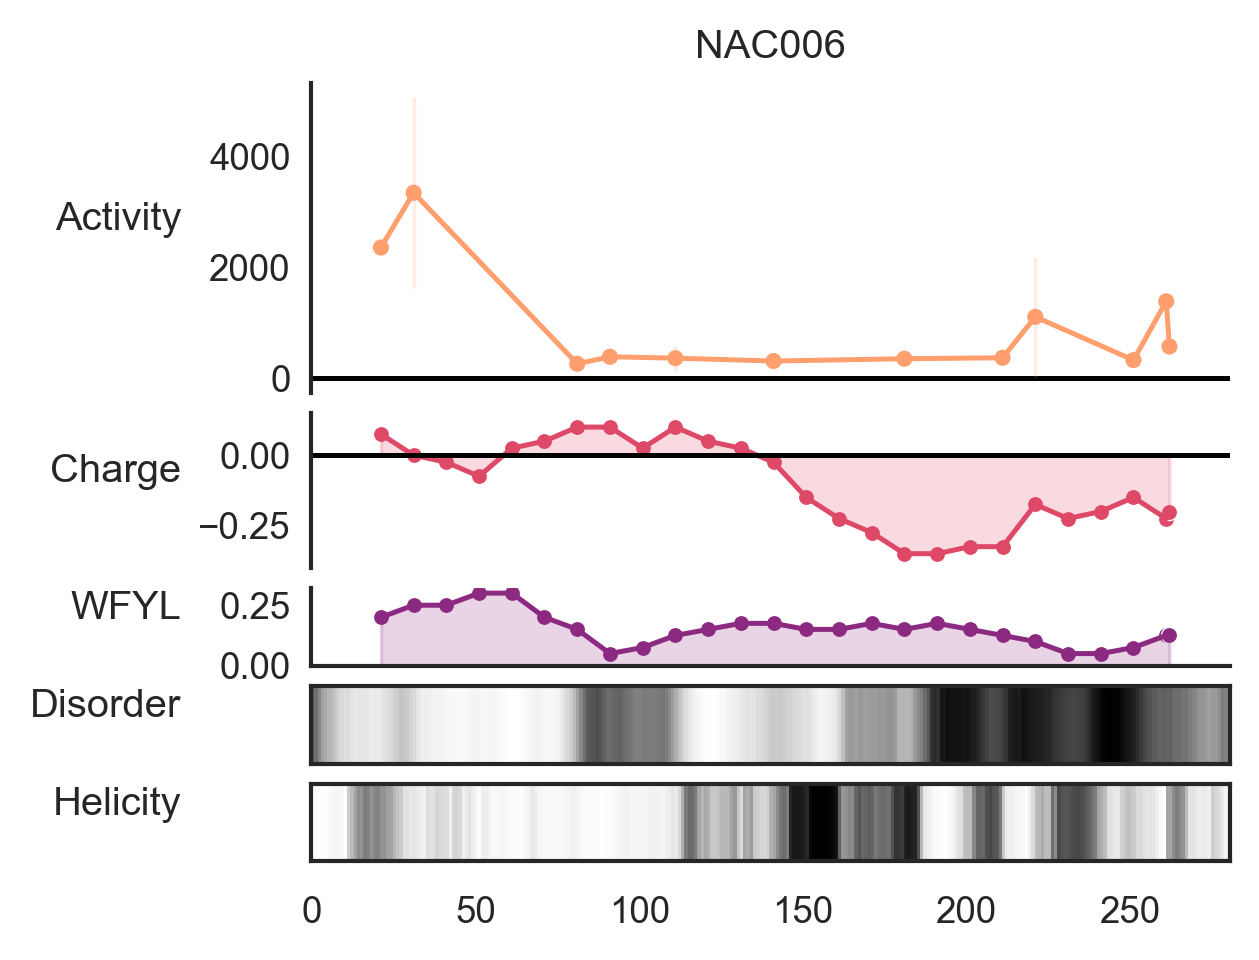

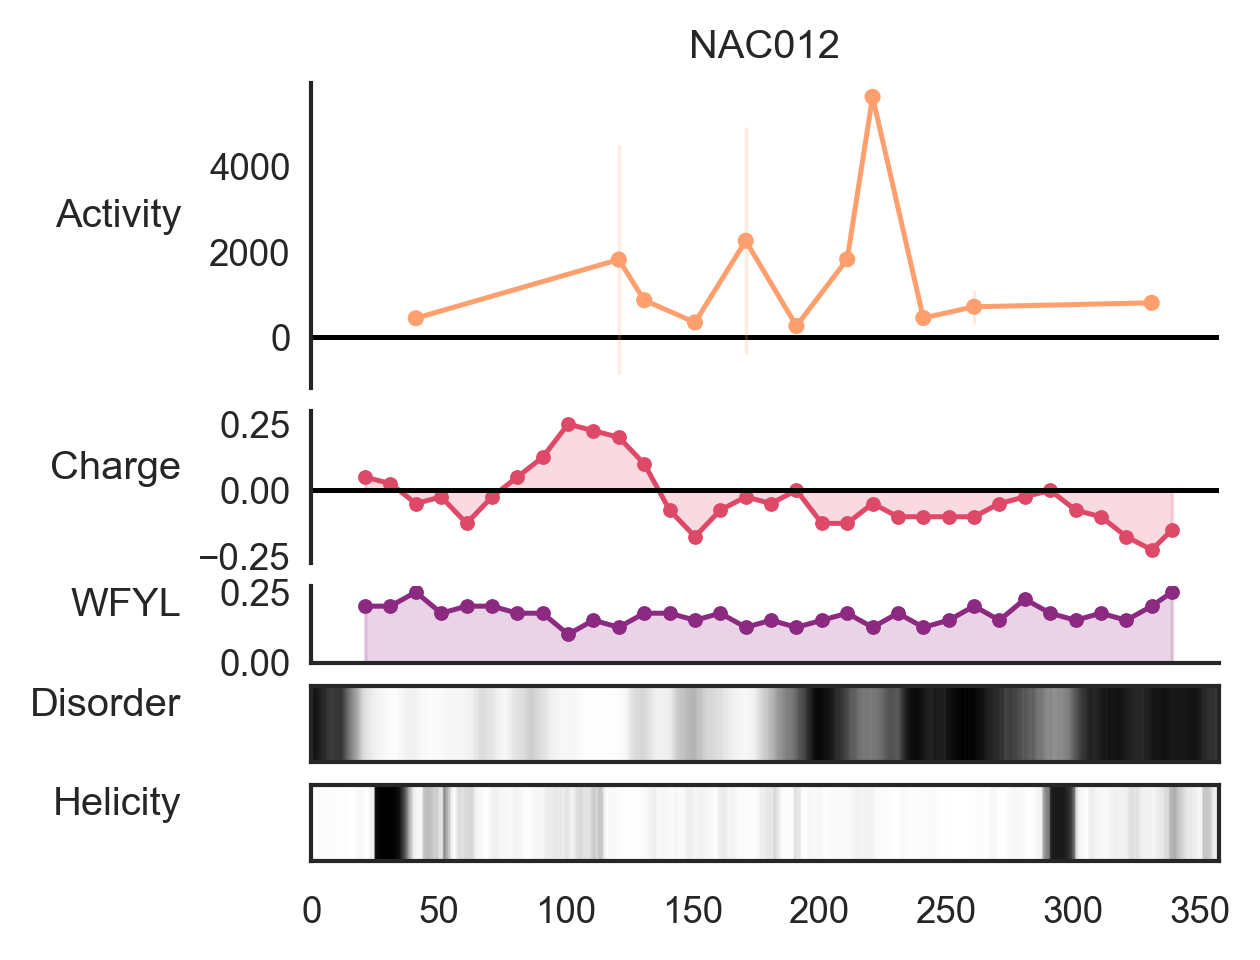

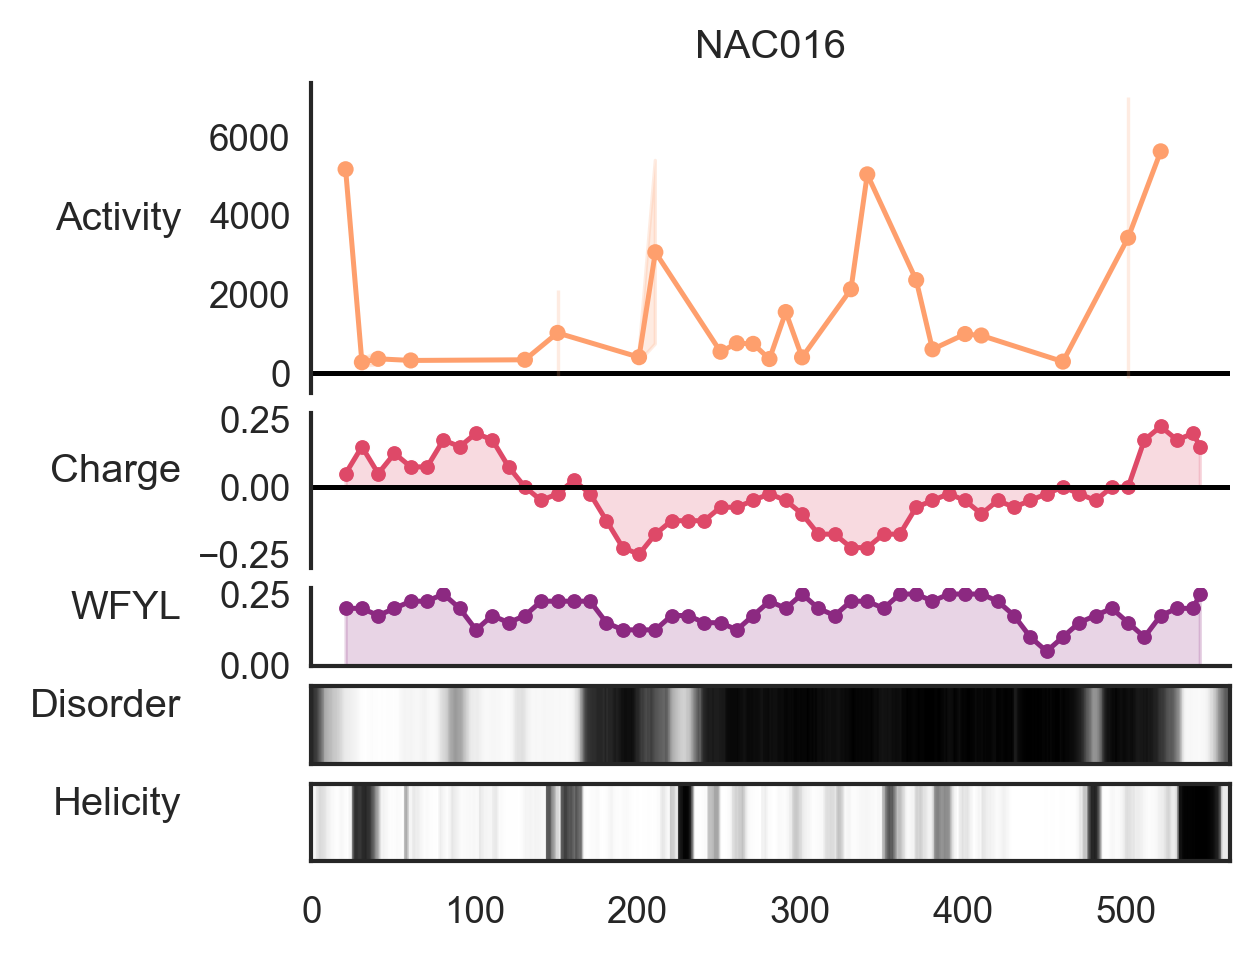

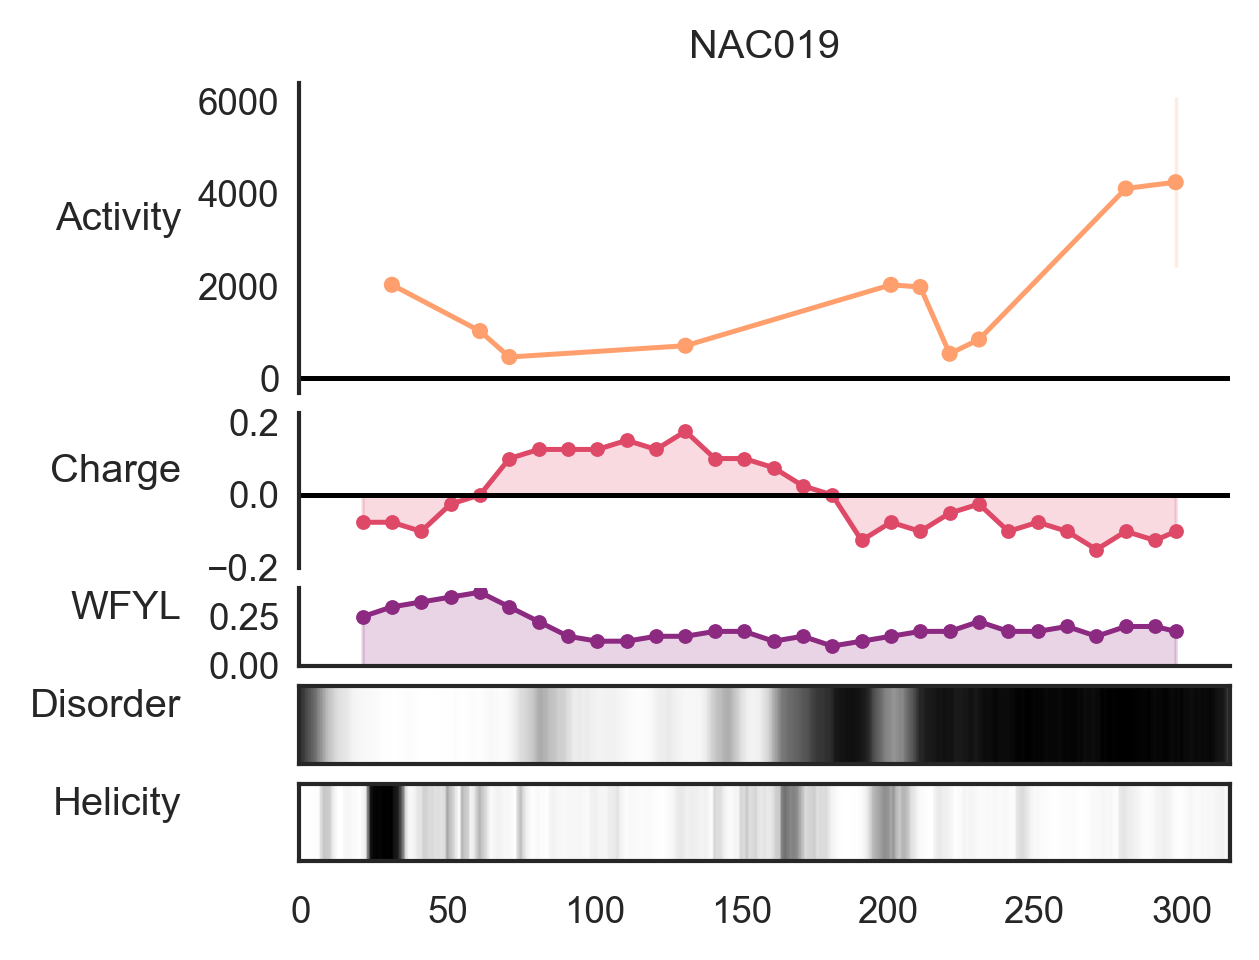

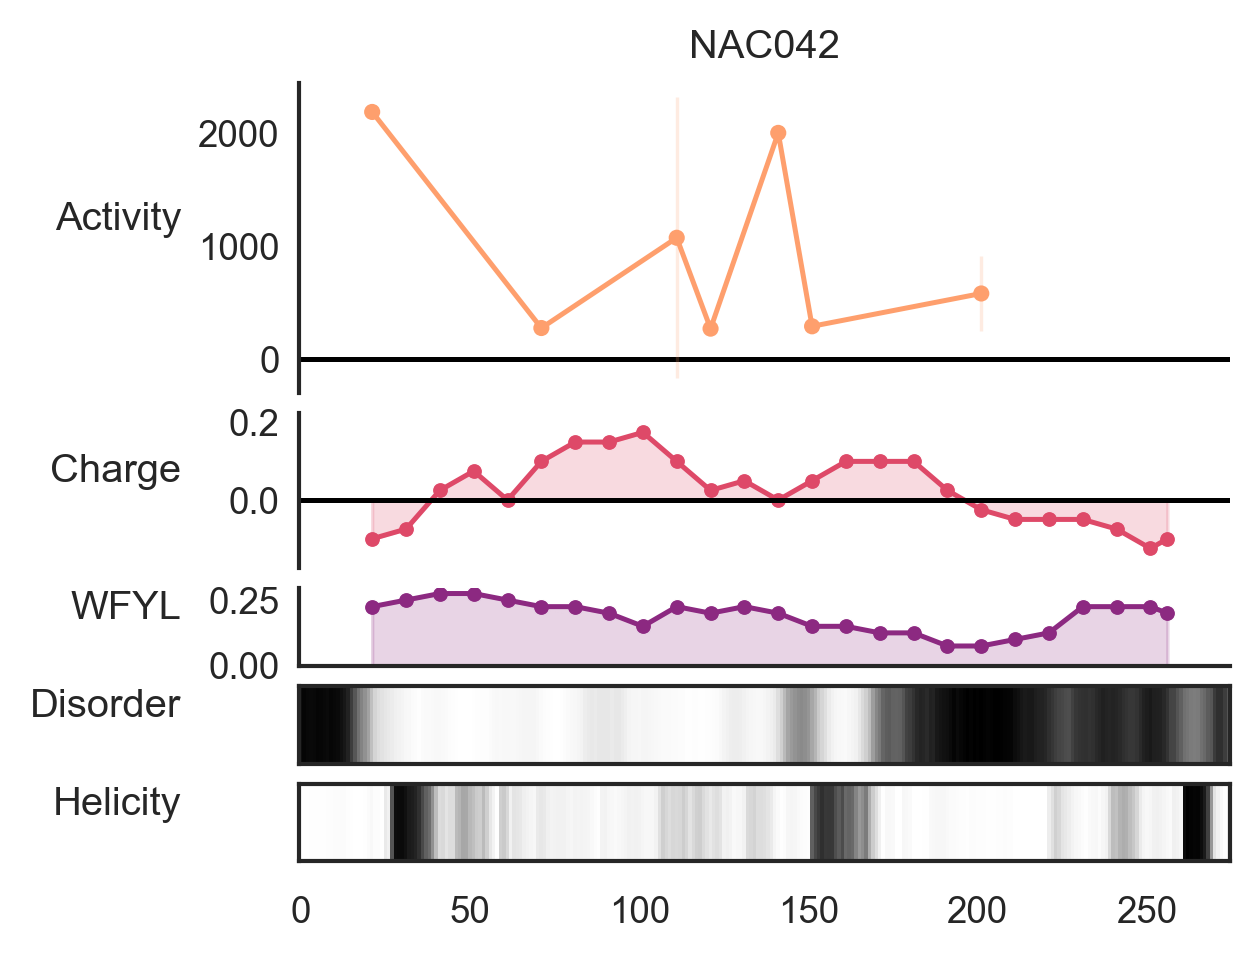

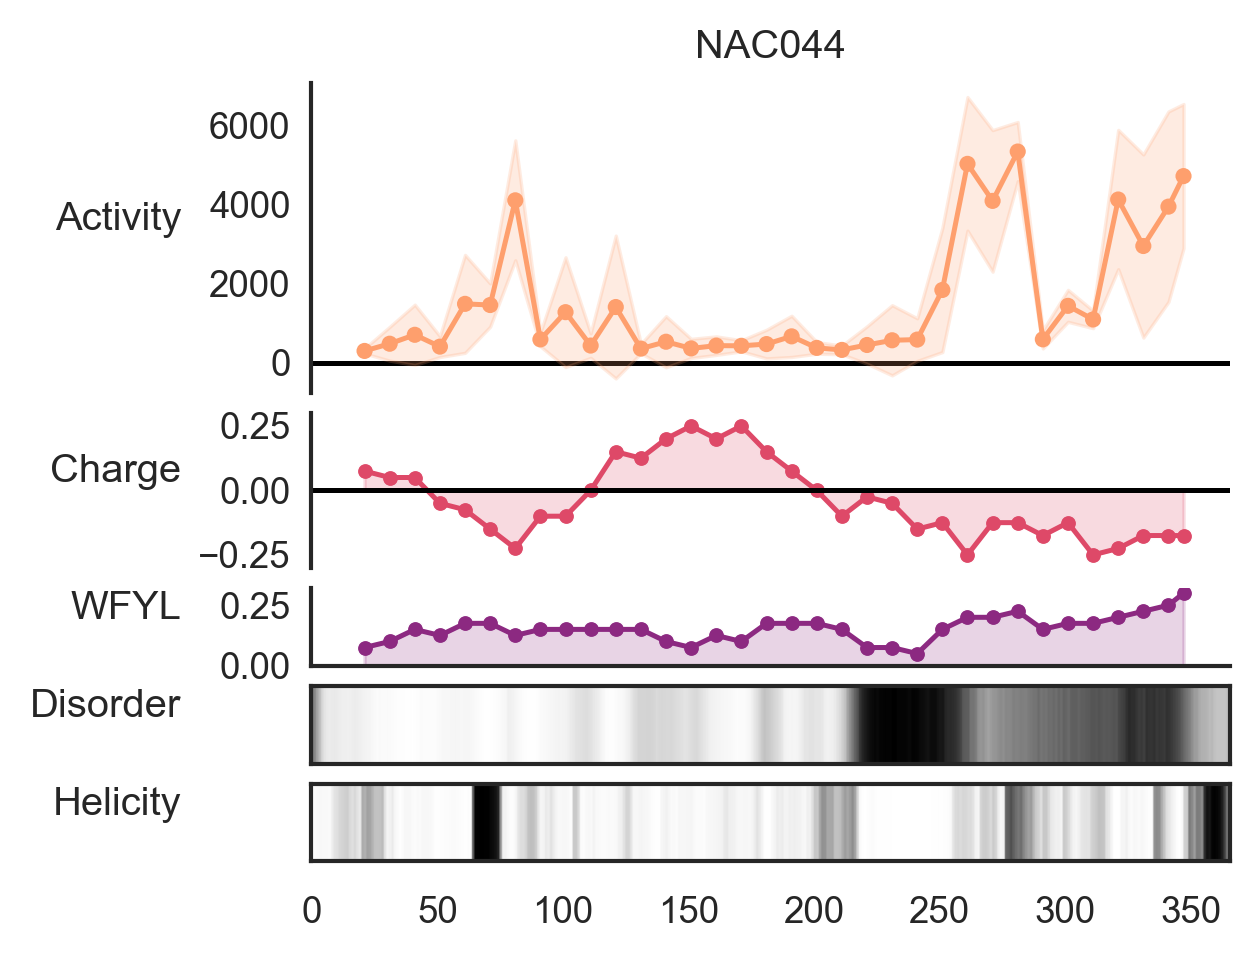

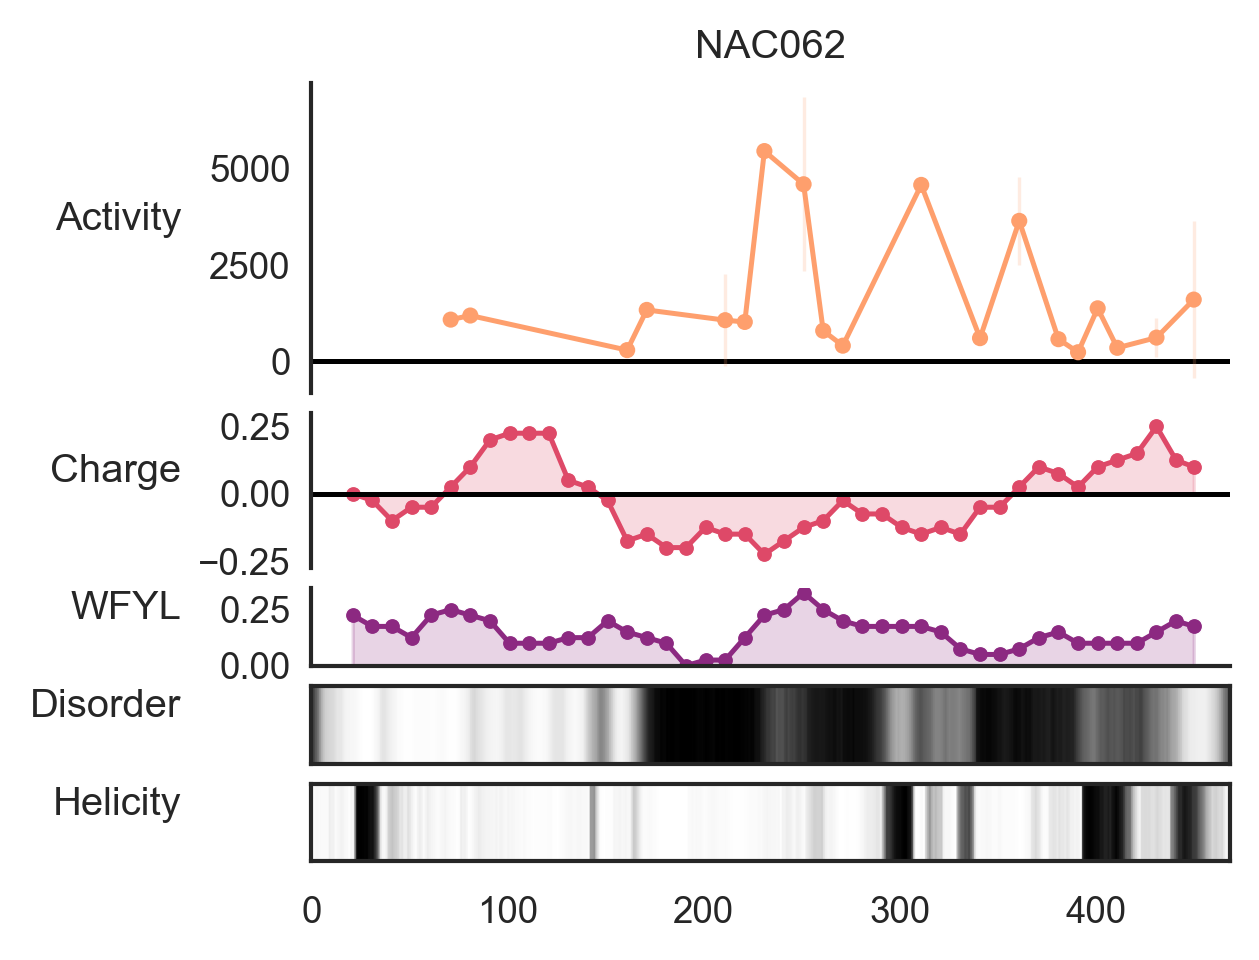

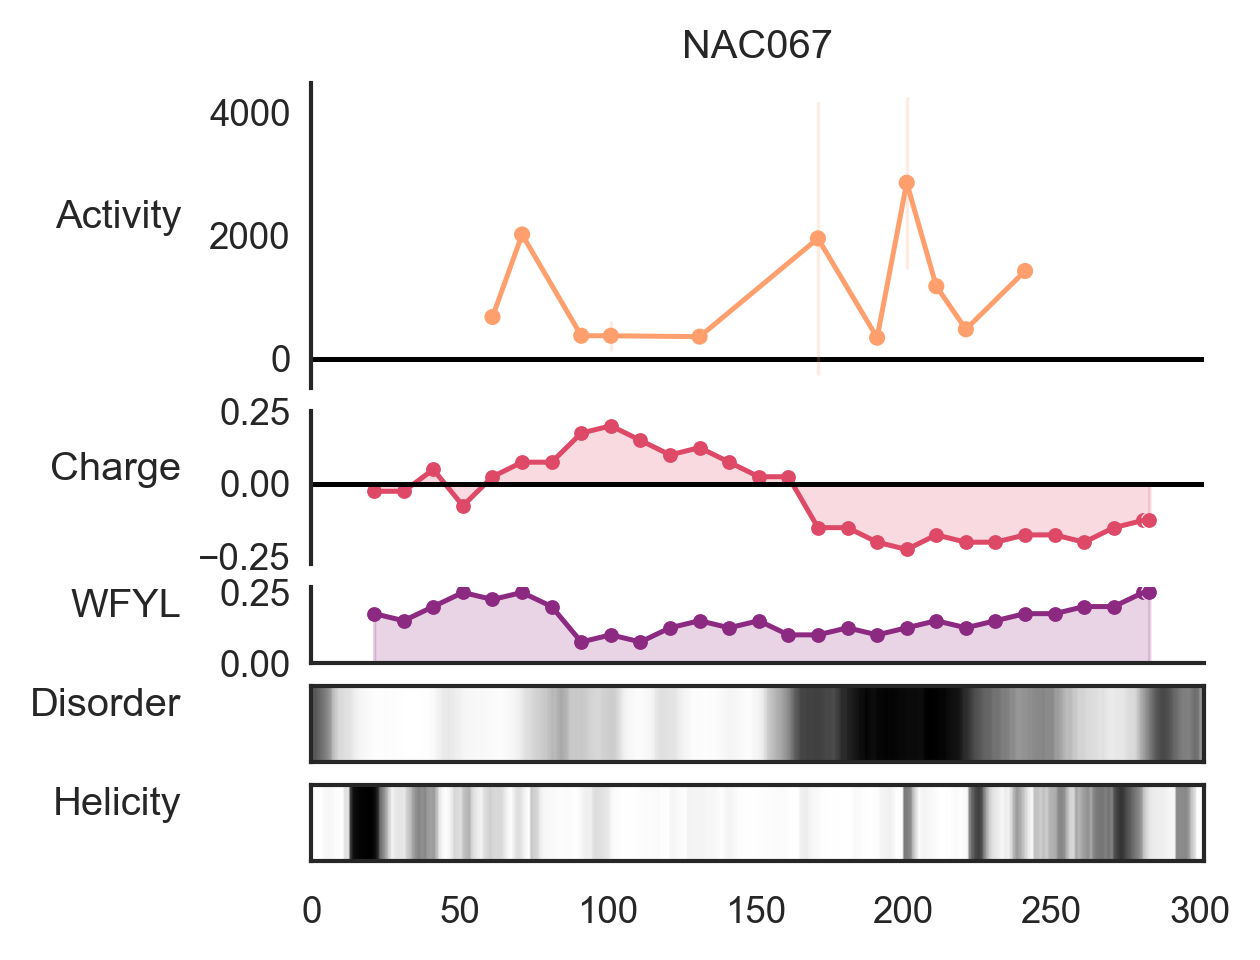

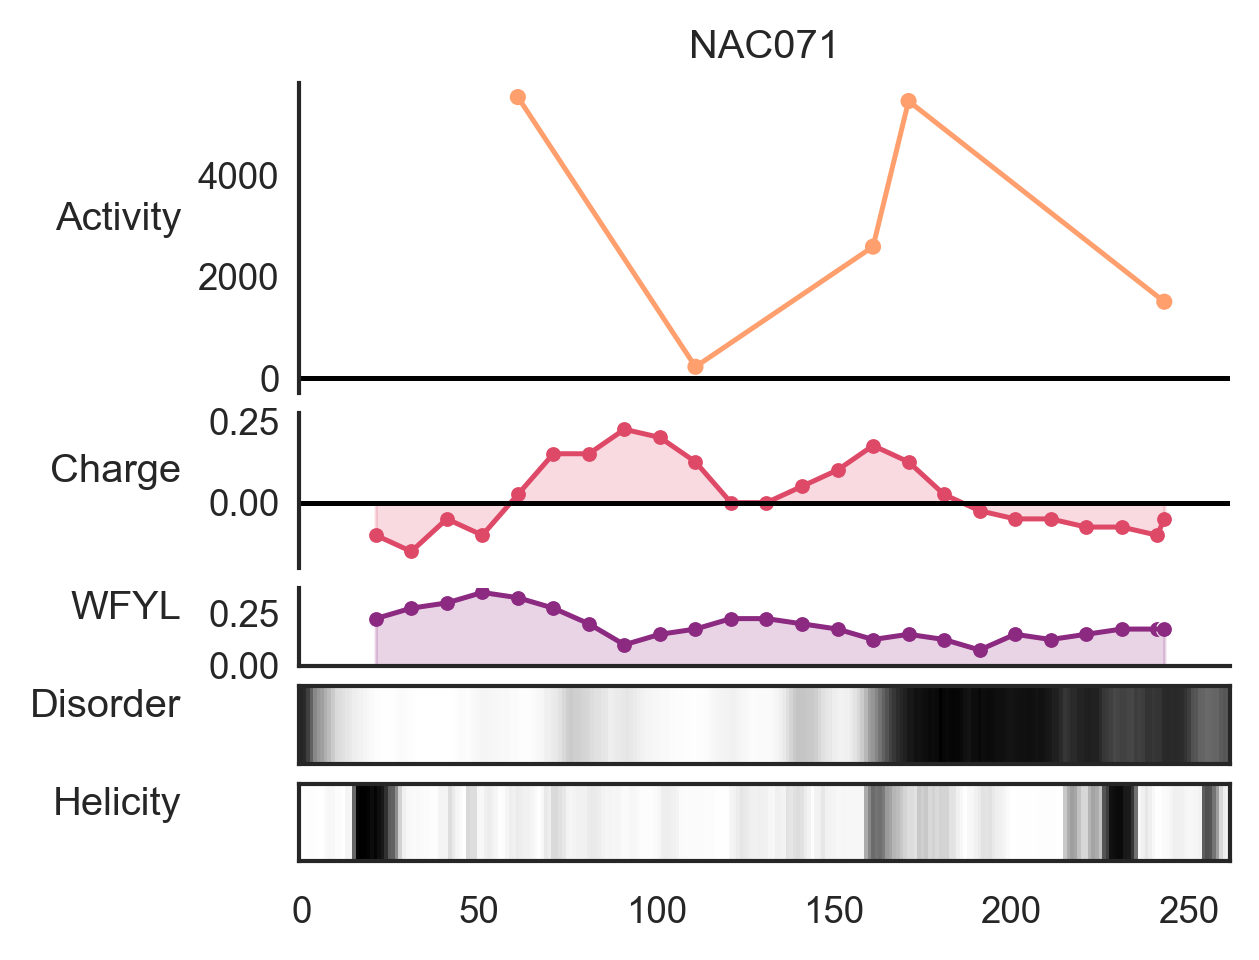

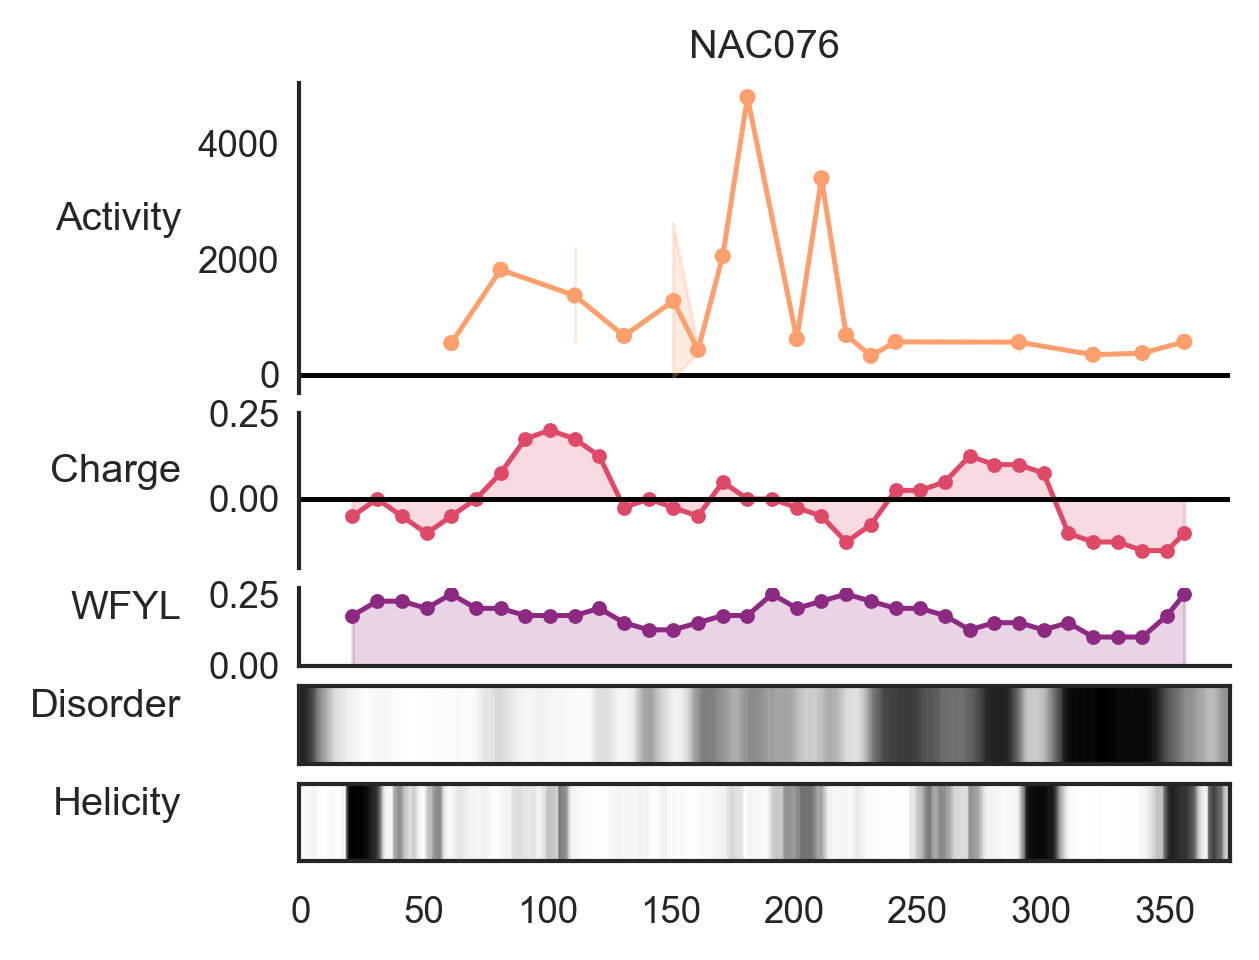

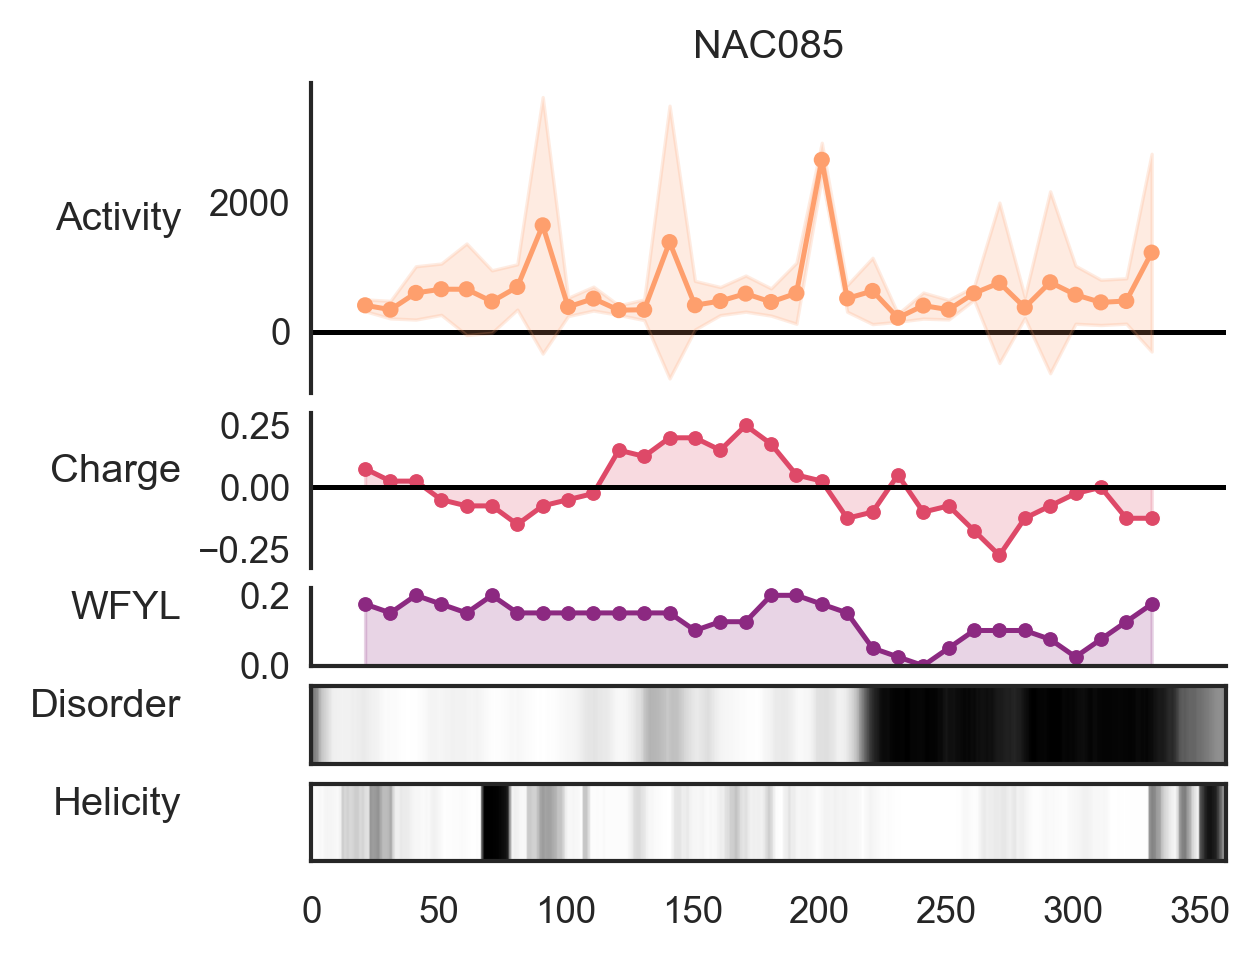

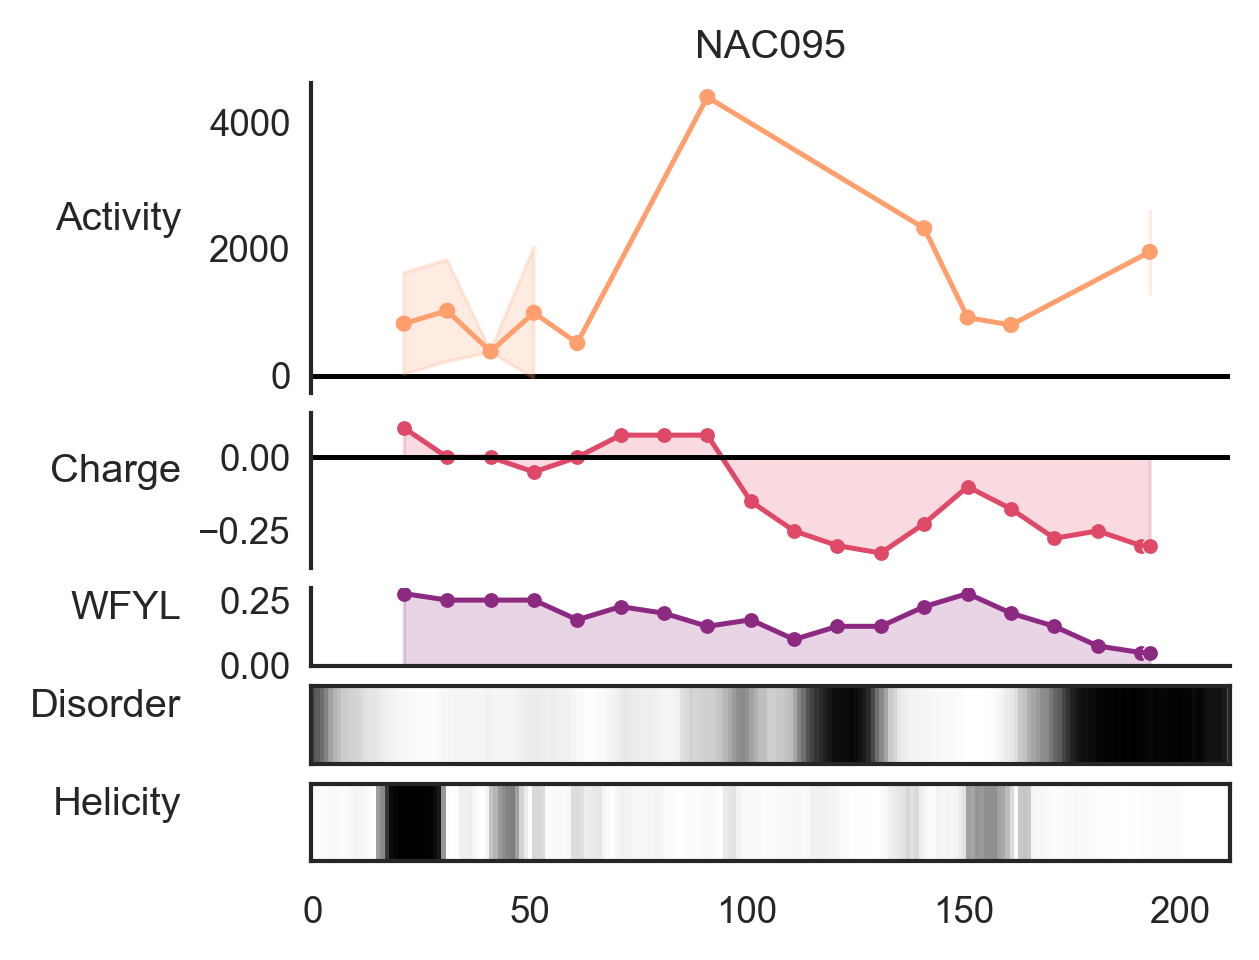

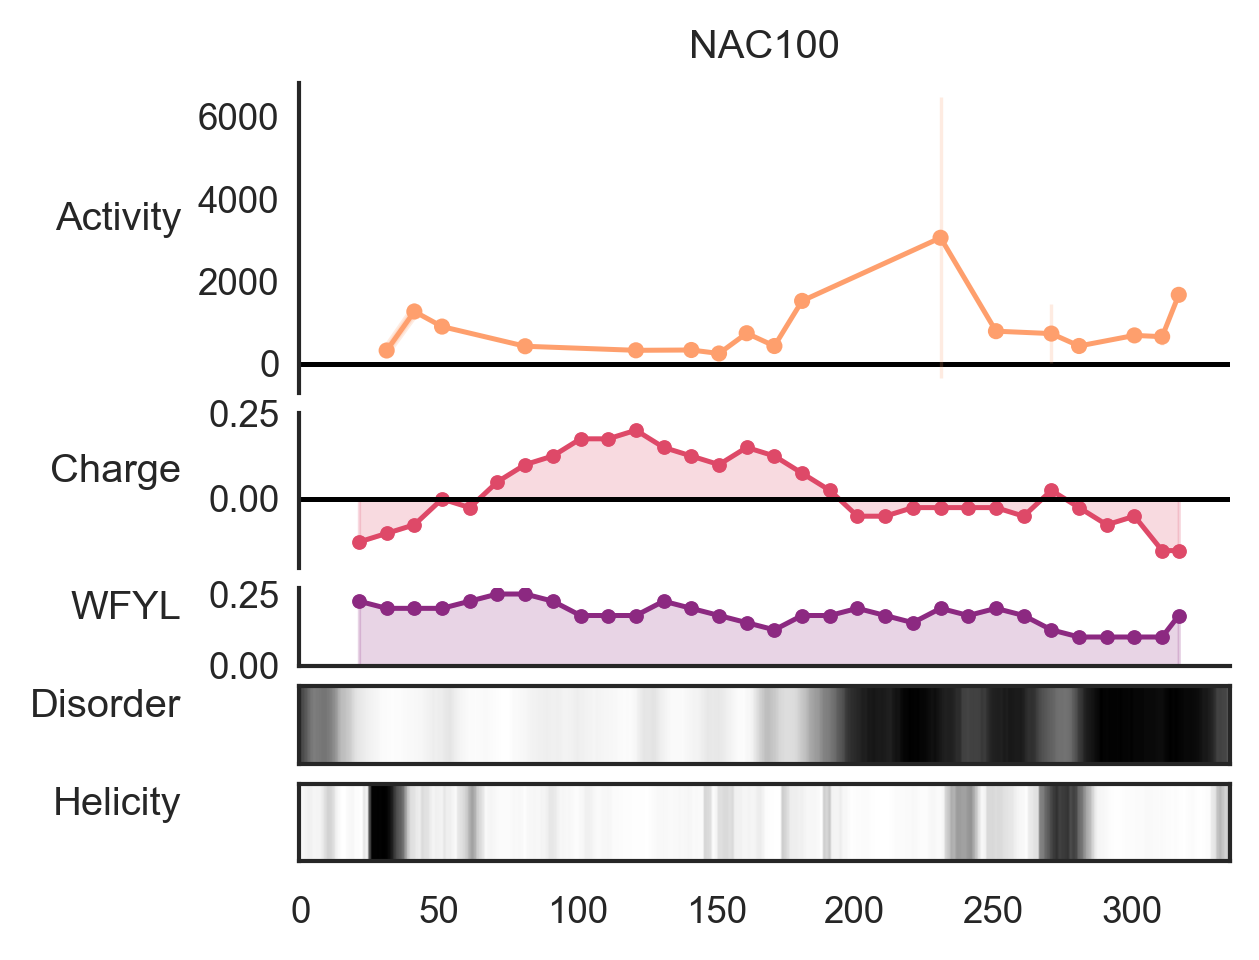

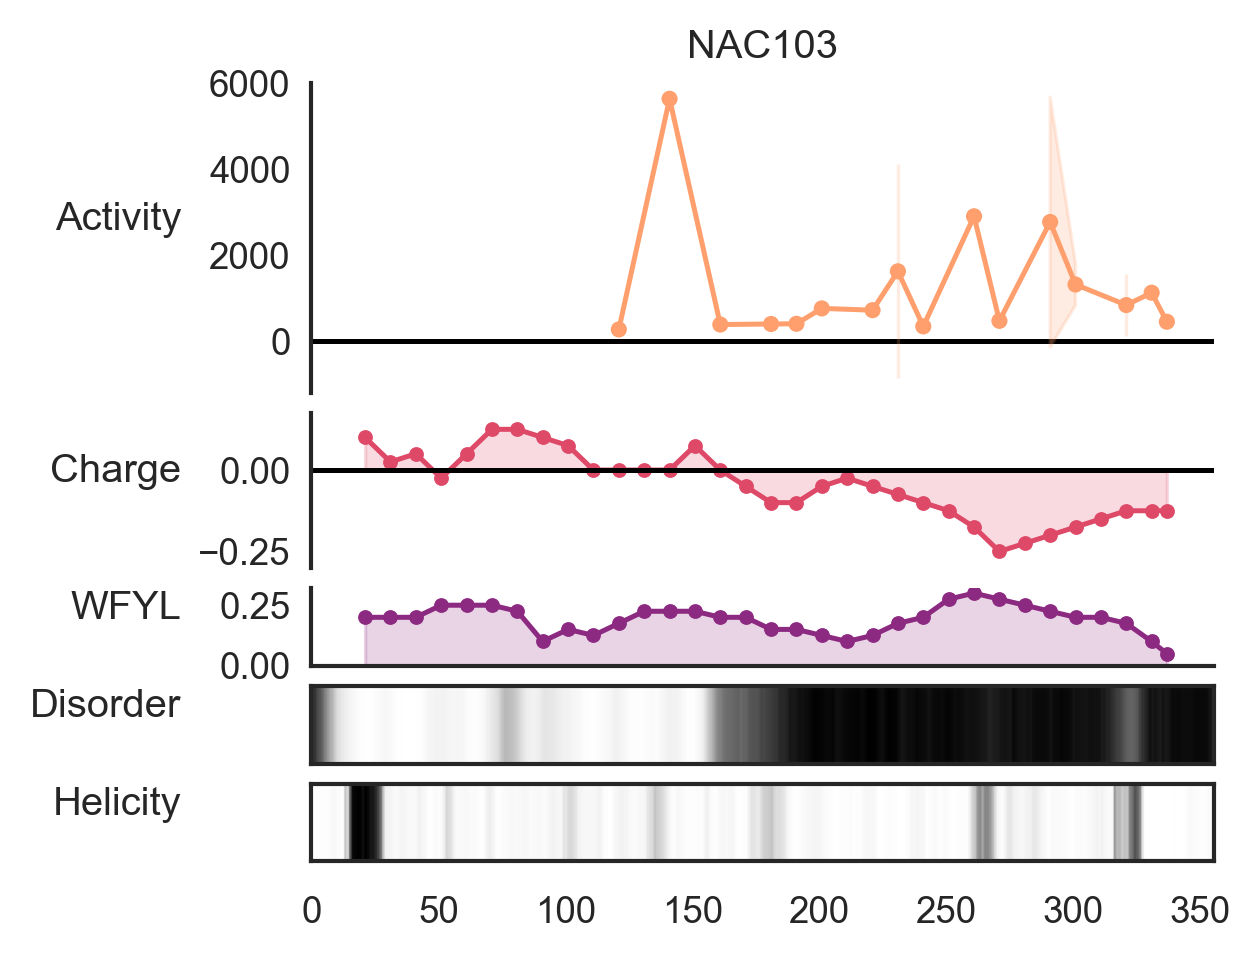

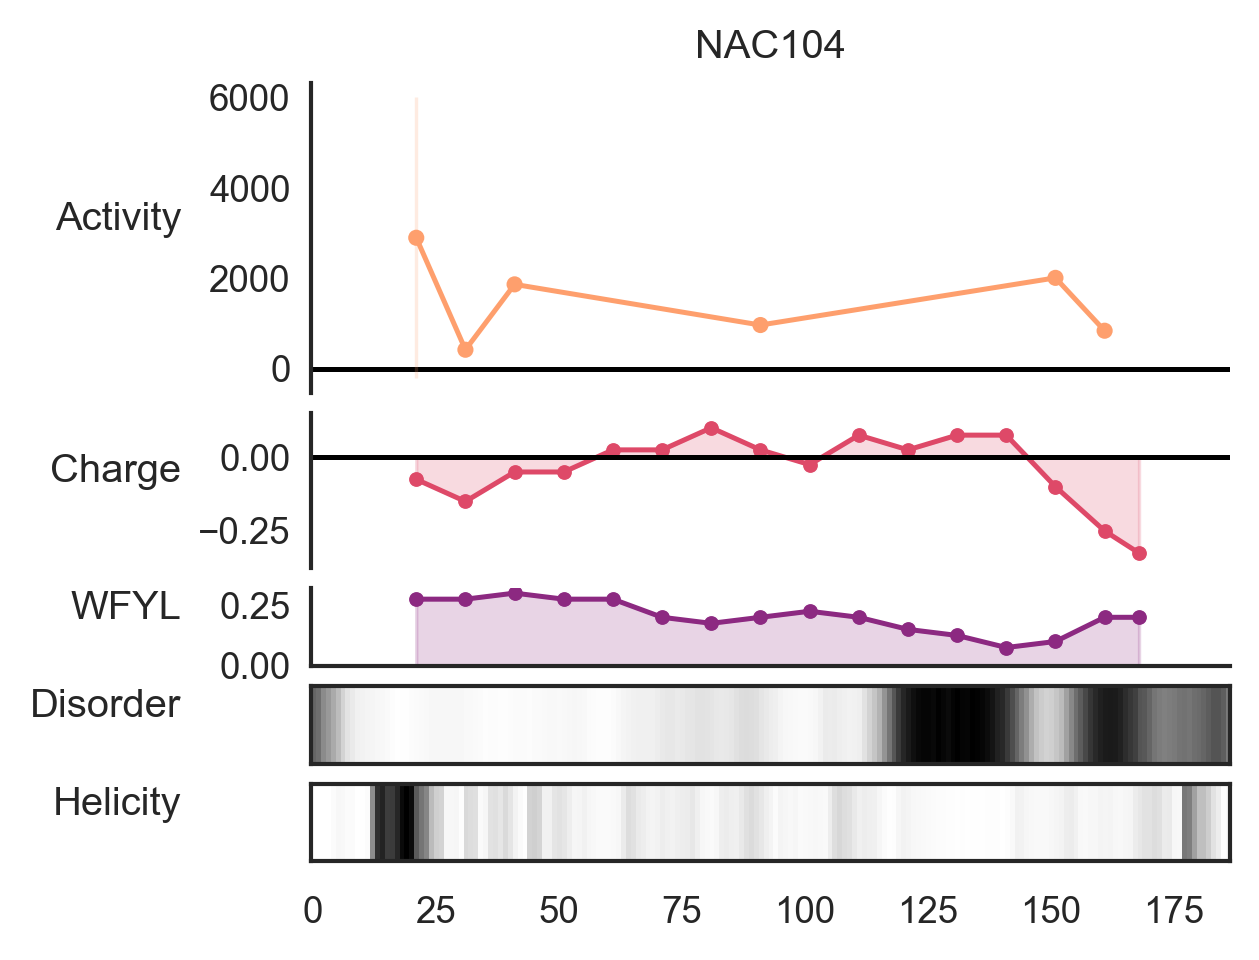

In [300]:
for nac_name in activity_dict.keys():
    plot_nac_fig(nac_name)

# 4. Repeat with EAEM